# PrediRuta: análisis, depuración y construcción de tablas para el proyecto

Este notebook parte de las tablas originales del `Portal de Datos de la Secretaría Distrital de Movilidad`. A partir de estas fuentes se revisan las relaciones entre las tablas, se aplican reglas de calidad sobre los datos y se construye una base depurada que servirá como punto de partida para el desarrollo del modelo.

**Modelo final:**

- `ACCIDENTE`: contiene una fila por cada siniestro válido, junto con su ubicación, fecha, hora y variable objetivo. Las tablas `MUERTO` y `LESIONADO` se utilizan durante la validación, pero no se exportan porque esta información queda representada en `ACTOR_VIAL`.

- `VIA`: reúne las condiciones de la vía asociadas a cada accidente.

- `CLIMA`: contiene las observaciones meteorológicas horarias obtenidas de Open-Meteo. Se utiliza ERA5 (`0,25°`, aproximadamente 25–28 km) para los periodos anteriores a 2017 y ECMWF IFS (aproximadamente 9 km) desde 2017. Cada accidente se asocia con el nodo meteorológico que realmente devuelve la API.

- `VEHICULO`: contiene los vehículos asociados a cada accidente. Se elimina la columna de placa por tratarse de un dato sensible.

- `ACTOR_VIAL`: contiene los involucrados en cada accidente de forma anonimizada, junto con las características necesarias para el análisis.

- `CAUSA`: reúne las causas registradas y su relación con el accidente o con los vehículos involucrados.

## 0. Configuración y criterios

In [58]:
# Importar librerías necesarias
from pathlib import Path
import unicodedata
import time
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt
from shapely.geometry import Point
import random # Usado para generar un tiempo de espera aleatorio entre las solicitudes a la API
from shapely import voronoi_polygons
from shapely.geometry import MultiPoint, box

In [59]:
# Configuración de rutas y directorios
DATA = Path('Data')  # Datos originales
SALIDA = Path('data_procesada/tablas_finales')  # Archivos CSV depurados
SALIDA.mkdir(parents=True, exist_ok=True)
CACHE_CLIMA = Path('data_procesada/cache_clima_hibrido') # Directorio para almacenar datos climáticos cacheados
CACHE_CLIMA.mkdir(parents=True, exist_ok=True)

# Definición de fuentes de datos
FUENTES = {
    'ACCIDENTE': 'ACCIDENTE.csv',
    'ACTOR_VIAL': 'VM_ACC_ACTOR_VIAL.csv',
    'LESIONADO': 'LESIONADO.csv',
    'MUERTO': 'MUERTO.csv',
    'VEHICULO': 'VM_ACC_VEHICULO.csv',
    'CAUSA': 'VM_ACC_CAUSA.csv',
    'VIA': 'VM_ACC_VIA.csv',
}

# Ruta del perímetro urbano oficial
RUTA_PERIMETRO_URBANO = DATA / 'perimetro_urbano_bogota.geojson'


In [60]:
# Funciones de limpieza y normalización de datos
def texto(s): # Función para limpiar y normalizar texto
    return s.astype('string').str.strip().replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

def normalizar_categoria(s): # Función para normalizar categorías de texto
    s = texto(s).str.upper()
    return s.map(lambda x: unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode() if pd.notna(x) else pd.NA)

def si_no(s): # Función para convertir respuestas de sí/no a valores binarios
    return normalizar_categoria(s).map({'S': 1, 'SI': 1, 'N': 0, 'NO': 0}).astype('Int64')

def leer(nombre, usecols=None): # Función para leer archivos CSV de las fuentes de datos
    return pd.read_csv(DATA / FUENTES[nombre], usecols=usecols, encoding='utf-8-sig', low_memory=False)

## 1. Inventario y análisis de la base original

In [61]:
# Inventario de archivos y tablas
inventario = []

# Recorrer las fuentes de datos y obtener información sobre filas y columnas
for nombre, archivo in FUENTES.items():
    ruta = DATA / archivo
    encabezado = pd.read_csv(ruta, nrows=0, encoding='utf-8-sig')
    with ruta.open('rb') as f:
        filas = sum(1 for _ in f) - 1
    inventario.append({'tabla': nombre, 'archivo': archivo, 'filas': filas, 'columnas': len(encabezado.columns)})

inventario = pd.DataFrame(inventario)
display(inventario)

,tabla,archivo,filas,columnas
0,ACCIDENTE,ACCIDENTE.csv,904476,23
1,ACTOR_VIAL,VM_ACC_ACTOR_VIAL.csv,3273697,15
2,LESIONADO,LESIONADO.csv,481423,19
3,MUERTO,MUERTO.csv,15890,21
4,VEHICULO,VM_ACC_VEHICULO.csv,2808440,10
5,CAUSA,VM_ACC_CAUSA.csv,1870450,11
6,VIA,VM_ACC_VIA.csv,965149,29


### ¿Cuáles variables retiramos?

Para reducir data que no será útil para el modelo a construir o data sensible, se retiran las siguientes variables:

| Fuente | Variables que se retiran | Motivo |
|---|---|---|
| **ACCIDENTE** | `OBJECTID`, fechas separadas, nombres de mes y día, `X`, `Y`, `LOCALIDAD`, campos repetidos y fechas de muerte | Son identificadores técnicos o información redundante; la ubicación se conserva mediante las coordenadas estandarizadas. |
| **VIA** | Identificadores de carga y “otra condición” | Pueden ser redundantes, llegar a generar dispeción o difíciles de modelar. Se conserva la vía principal y sus condiciones relevantes. |
| **VEHICULO** | `OBJECTID`, `PLACA`, `CODIGO` y `FORMULARIO` | La placa es sensible; los demás son campos técnicos o llaves redundantes. |
| **ACTOR_VIAL** | `OBJECTID`, fecha de nacimiento, códigos técnicos y formulario | Se evita información personal o redundante; se conservan edad, género, condición y estado. Los accidentes con edades imposibles se excluyen durante la revisión estadística. |
| **LESIONADO y MUERTO** | Tablas completas | Son tablas especializadas que se solapan con `ACTOR_VIAL`; se usan para validar. |
| **CAUSA** | `OBJECTID`, `CODIGO`, `CODIGO_AC_VH`, formulario y campos repetidos | Son identificadores técnicos o combinaciones reconstruibles. |

Durante el notebook, se genera una revisión de la calidad de los datos y generan nuevas columnas; sin embargo, no se almacenan en la BD final. La data final solo se llevarán registros válidos.

### Claves y relaciones por la estructura de la BD original

| Tabla principal | Campo Princial | Tabla relacionada| Campo Relacionado| Relación |
|-------------|------------------|-------------|------------------|--------------|
| ACCIDENTE   | FORMULARIO       | ACTOR_VIAL  | FORMULARIO       | 1:N          |
| ACCIDENTE   | FORMULARIO       | LESIONADO   | FORMULARIO       | 1:N          |
| ACCIDENTE   | FORMULARIO       | MUERTO      | FORMULARIO       | 1:N          |
| ACCIDENTE   | FORMULARIO       | VEHICULO    | FORMULARIO       | 1:N          |
| ACCIDENTE   | FORMULARIO       | CAUSA       | FORMULARIO       | 1:N          |
| ACCIDENTE   | CODIGO_ACCIDENTE | VIA         | CODIGO_ACCIDENTE | 1:N          |

## 2. Limpieza y validación de `ACCIDENTE`

PrediRuta diferencia entre los problemas de calidad del dato y los criterios definidos para delimitar el proyecto. Primero se normalizan los identificadores, fechas, horas y coordenadas, sin completar valores faltantes de forma artificial. Después se verifica si cada accidente corresponde al periodo de análisis y si se encuentra dentro del perímetro urbano definido. De esta manera, es posible diferenciar los registros que se descartan por problemas en la información de aquellos que simplemente están fuera del alcance espacial o temporal del proyecto.

El proyecto se concentra en la **zona urbana de Bogotá**, donde se cuenta con una mayor cobertura de registros de accidentalidad para construir y validar el modelo. Para definir este límite se utiliza el GeoJSON oficial del **Perímetro urbano POT Bogotá D.C.**, publicado por la Secretaría Distrital de Planeación. Los accidentes registrados en zonas rurales, incluida Sumapaz, se conservan en la fuente original, pero se excluyen del conjunto utilizado para el modelado. Tanto las coordenadas de los accidentes como el perímetro urbano se manejan en `EPSG:4326` para realizar la validación espacial.

Fuente: https://datosabiertos.bogota.gov.co/dataset/perimetro-urbano-bogota-d-c


In [62]:
# Limpieza inicial de la tabla ACCIDENTE
a = leer('ACCIDENTE')

# Normalización de texto y conversión de tipos de datos
formulario_original = a['FORMULARIO'].astype('string')
hora_original = texto(a['HORA_OCURRENCIA_ACC'])

# Normalización de texto y conversión de tipos de datos
a['ACCIDENTE_ID'] = pd.to_numeric(
    texto(a['CODIGO_ACCIDENTE']), errors='coerce'
).astype('Int32')
a['FORMULARIO'] = texto(a['FORMULARIO'])
a['LATITUD'] = pd.to_numeric(texto(a['LATITUD']), errors='coerce')
a['LONGITUD'] = pd.to_numeric(texto(a['LONGITUD']), errors='coerce')

# Conversión de fecha y hora a un solo campo de fecha y hora
fecha_texto = texto(a['FECHA_OCURRENCIA_ACC']).str.slice(0, 10)
fecha_parseada = pd.to_datetime(fecha_texto, errors='coerce')
hora_valida = hora_original.str.match(r'^(?:[01]\d|2[0-3]):[0-5]\d(?::[0-5]\d)?$', na=False)
hora_parseada = pd.to_timedelta(hora_original.where(hora_valida), errors='coerce')
a['FECHA_HORA'] = fecha_parseada + hora_parseada

# Resumen de limpieza y validación de datos
resumen_limpieza = pd.DataFrame([
    ['Formularios normalizados', formulario_original.fillna('NULO').ne(a['FORMULARIO'].fillna('NULO')).sum()],
    ['Fechas con formato inválido o faltante', fecha_parseada.isna().sum()],
    ['Horas con formato inválido o faltante', (~hora_valida).sum()],
    ['Coordenadas incompletas después de convertir', (a['LATITUD'].isna() | a['LONGITUD'].isna()).sum()],
], columns=['validacion', 'registros'])

display(resumen_limpieza)


,validacion,registros
0,Formularios normalizados,10
1,Fechas con formato inválido o faltante,0
2,Horas con formato inválido o faltante,0
3,Coordenadas incompletas después de convertir,0


### Selección periodo a trabajar

Para definir el periodo de análisis, se revisa la cantidad de accidentes registrados por año. Esta revisión permite identificar años con pocos registros o con información incompleta y seleccionar un periodo con una cobertura suficiente para el desarrollo del proyecto.

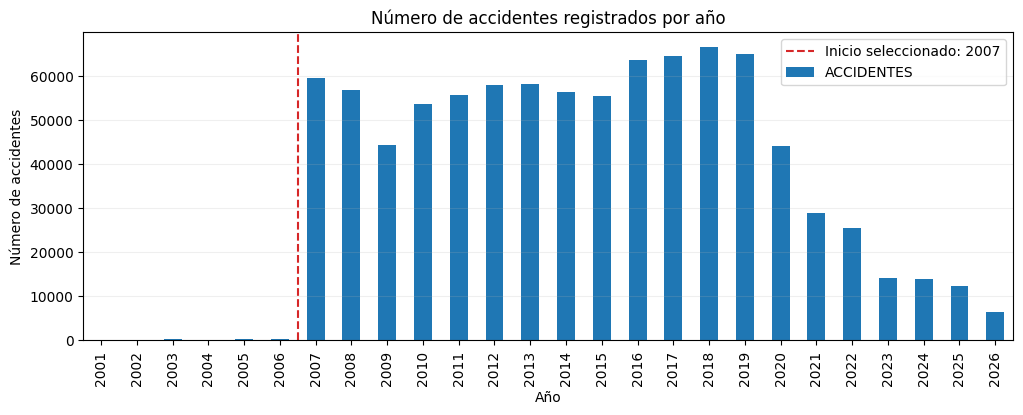

In [63]:
# Análisis de accidentes por año
# Creación de una serie temporal con el número de accidentes por año
accidentes_por_anio = (
    a.dropna(subset=['FECHA_HORA'])
    .assign(ANIO=lambda df: df['FECHA_HORA'].dt.year)
    .groupby('ANIO')
    .size()
)

# Agregación de años faltantes con valor cero para mantener la continuidad temporal
anios = range(int(accidentes_por_anio.index.min()), int(accidentes_por_anio.index.max()) + 1)
accidentes_por_anio = (
    accidentes_por_anio.reindex(anios, fill_value=0)
    .rename('ACCIDENTES')
    .rename_axis('ANIO')
    .reset_index()
)

# Visualización de la serie temporal de accidentes por año
ax = accidentes_por_anio.plot(
    x='ANIO', y='ACCIDENTES', kind='bar', figsize=(12, 4),
    color='#1f77b4', legend=False,
)
ax.axvline(5.5, color='#d62728', linestyle='--', label='Inicio seleccionado: 2007')
ax.set_title('Número de accidentes registrados por año')
ax.set_xlabel('Año')
ax.set_ylabel('Número de accidentes')
ax.legend()
ax.grid(axis='y', alpha=0.2)

Entre 2001 y 2006 la cantidad de registros de accidentabilidad es muy baja. Desde 2007 se observa un aumento importante y el número de registros se mantiene en decenas de miles por año, con una cobertura mucho más consistente. Por esta razón, se toma 2007 como inicio del periodo de análisis, evitando que la baja disponibilidad de datos de los primeros años pueda interpretarse como una disminución real de los accidentes.

In [64]:
PERIODO_INICIO = pd.Timestamp('2007-01-01')
PERIODO_FIN = pd.Timestamp.today().normalize() + pd.Timedelta(days=1)

### Obtención del perímetro urbano oficial

El perímetro urbano se toma directamente de la fuente oficial. Si el archivo ya se encuentra disponible en `Data`, se reutiliza; de lo contrario, se descarga nuevamente. Se conserva la geometría original para trabajar con el límite real de la zona urbana de Bogotá, tanto en la validación de las coordenadas como en la representación espacial de los resultados.


In [65]:
# Descarga del perímetro urbano oficial si aún no existe localmente
URL_PERIMETRO_URBANO = (
    'https://datosabiertos.bogota.gov.co/dataset/12a704ee-e5bb-4c5d-bad6-a5069d12f90a/resource/2b5ed242-8e16-4afb-9f85-13790170f874/download/perimetrourbano.json'
)

if not RUTA_PERIMETRO_URBANO.exists():
    respuesta = requests.get(URL_PERIMETRO_URBANO, timeout=120)
    respuesta.raise_for_status()
    RUTA_PERIMETRO_URBANO.write_bytes(respuesta.content)

perimetro_urbano = gpd.read_file(RUTA_PERIMETRO_URBANO)

### Componentes separados del perímetro urbano

El perímetro urbano oficial de Bogotá está compuesto por varios polígonos, por lo que en el mapa aparecen algunas zonas separadas del polígono principal. Estas áreas no corresponden a errores en las coordenadas, sino que hacen parte del recurso oficial e incluyen sectores como Soratama, Villas del Cerro y Mirador del Norte. Por esta razón, se mantienen dentro del perímetro utilizado en el proyecto.

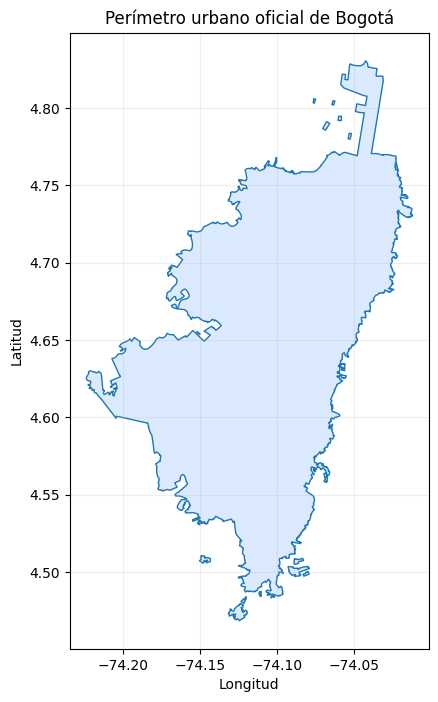

In [66]:
# Visualización del perímetro urbano oficial de Bogotá
perimetro_urbano = perimetro_urbano.to_crs('EPSG:4326')
geometria_urbana = (
    perimetro_urbano.geometry.union_all()
    if hasattr(perimetro_urbano.geometry, 'union_all')
    else perimetro_urbano.geometry.unary_union
)

# Visualización del perímetro urbano oficial de Bogotá
ax = perimetro_urbano.plot(figsize=(7, 8), facecolor='#dbeafe', edgecolor='#1f77b4', linewidth=1)
ax.set_title('Perímetro urbano oficial de Bogotá')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.grid(alpha=0.2)

**Nota:** Las geometrías separadas del polígono principal también hacen parte del perímetro urbano oficial de Bogotá e incluyen sectores como Soratama, Villas del Cerro y Mirador del Norte. Estas zonas se conservan dentro del análisis para evitar excluir accidentes ubicados en sectores que oficialmente pertenecen al área urbana.

### Validación espacial de las coordenadas

Las coordenadas ya convertidas se transforman en puntos geográficos y se comparan con el perímetro urbano de Bogotá. Esta validación permite identificar cuántos accidentes se encuentran dentro o fuera del área definida para el proyecto. En esta etapa todavía no se eliminan registros, ya que este resultado se combina más adelante con los demás criterios de calidad y alcance.

In [67]:
# Creación de un GeoDataFrame con los puntos de accidentes
puntos = gpd.GeoDataFrame(
    a[['ACCIDENTE_ID','LATITUD','LONGITUD']].copy(),
    geometry=gpd.points_from_xy(a['LONGITUD'], a['LATITUD']),
    crs='EPSG:4326',
)

In [68]:
# Clasificación de los puntos según su ubicación geográfica respecto al límite de Bogotá
coord_valida = puntos.geometry.intersects(geometria_urbana)
resultado_espacial = pd.Series(
    np.where(coord_valida, 'Dentro del perímetro urbano', 'Fuera del perímetro urbano'),
    name='resultado',
).value_counts().rename_axis('clasificacion').reset_index(name='registros')

# Cálculo del porcentaje de registros dentro y fuera del perímetro urbano
resultado_espacial['porcentaje'] = (resultado_espacial['registros'] / len(puntos) * 100).round(2)
display(resultado_espacial)

,clasificacion,registros,porcentaje
0,Dentro del perímetro urbano,897110,99.19
1,Fuera del perímetro urbano,7366,0.81


### Consistencia entre pares de coordenadas

La fuente incluye dos formas de representar la ubicación de cada accidente: `X/Y` y `LONGITUD/LATITUD`. En esta validación se comparan ambos pares usando una pequeña tolerancia para identificar posibles diferencias entre ellos. El resultado se utiliza como una revisión de consistencia de la fuente y no como un criterio directo de exclusión, ya que la ubicación que finalmente se utiliza también se valida contra el perímetro urbano oficial.

In [69]:
# Validación de la consistencia entre las coordenadas X/Y y LONGITUD/LATITUD
x_original = pd.to_numeric(a['X'], errors='coerce').to_numpy(dtype='float64', na_value=np.nan)
y_original = pd.to_numeric(a['Y'], errors='coerce').to_numpy(dtype='float64', na_value=np.nan)
longitud_limpia = a['LONGITUD'].to_numpy(dtype='float64', na_value=np.nan)
latitud_limpia = a['LATITUD'].to_numpy(dtype='float64', na_value=np.nan)

# Comparación de las coordenadas X/Y con LONGITUD/LATITUD usando tolerancia para valores cercanos
ejes_coinciden = (
    np.isclose(x_original, longitud_limpia, atol=0.000001, rtol=0, equal_nan=False)
    & np.isclose(y_original, latitud_limpia, atol=0.000001, rtol=0, equal_nan=False)
)

display(pd.DataFrame([
    ['Coordenadas X/Y que coinciden', ejes_coinciden.sum()],
    ['Coordenadas X/Y con diferencias', (~ejes_coinciden).sum()],
], columns=['resultado', 'cantidad']))

,resultado,cantidad
0,Coordenadas X/Y que coinciden,904475
1,Coordenadas X/Y con diferencias,1


La comparación muestra una alta consistencia entre ambos pares de coordenadas. Esto indica que ambas representaciones de la ubicación son prácticamente equivalentes en la fuente; el único caso diferente se mantiene identificado para su revisión sin afectar el resto del análisis.

### Separación entre calidad y alcance

La calidad del dato se revisa primero para verificar que cada accidente pueda identificarse correctamente y que cuente con fecha, hora y coordenadas válidas. De forma separada, se valida si el registro se encuentra dentro del periodo y del perímetro definidos para PrediRuta. Solo los accidentes que cumplen ambas condiciones se consideran utilizables para el proyecto. La variable `GRAVEDAD` se revisa aparte, ya que solo es necesaria para los análisis relacionados con la severidad.

In [70]:
# Análisis de calidad estructural y alcance analítico de los registros de accidentes
# Condiciones necesarias para identificar y ubicar el accidente en el tiempo y el espacio
qa_estructura = pd.DataFrame({
    'id_completo': a['ACCIDENTE_ID'].notna(),
    'id_unico': a['ACCIDENTE_ID'].notna() & ~a['ACCIDENTE_ID'].duplicated(keep=False),
    'formulario_completo': a['FORMULARIO'].notna(),
    'formulario_unico': a['FORMULARIO'].notna() & ~a['FORMULARIO'].duplicated(keep=False),
    'fecha_con_formato': fecha_parseada.notna(),
    'hora_con_formato': hora_valida,
    'latitud_posible': a['LATITUD'].between(-90, 90),
    'longitud_posible': a['LONGITUD'].between(-180, 180),
})

# Registros que cumplen con las condiciones de calidad estructural y alcance analítico
qa_alcance = pd.DataFrame({
    'fecha_en_periodo': a['FECHA_HORA'].between(PERIODO_INICIO, PERIODO_FIN, inclusive='left'),
    'coordenada_en_perimetro_urbano': coord_valida,
})

# Resumen de calidad estructural y alcance
a['DATOS_VALIDOS'] = qa_estructura.all(axis=1)
a['DENTRO_ALCANCE'] = qa_alcance.all(axis=1)
a['REGISTRO_UTILIZABLE'] = a['DATOS_VALIDOS'] & a['DENTRO_ALCANCE']
a['UTILIZABLE_PARA_SEVERIDAD'] = a['REGISTRO_UTILIZABLE'] & texto(a['GRAVEDAD']).notna()

### Resultado de las reglas de validación

A continuación se revisa el cumplimiento de cada regla de validación por separado. Esto permite identificar si los registros que no continúan en el análisis presentan problemas en la estructura de los datos o simplemente quedan por fuera del alcance definido para PrediRuta.

In [71]:
# Función para generar un reporte de criterios de calidad
def reporte_criterios(criterios):
    return pd.DataFrame({
        'criterio': criterios.columns,
        'cumplen': criterios.sum().to_numpy(),
        'no_cumplen': (~criterios).sum().to_numpy(),
        'porcentaje_cumple': criterios.mean().mul(100).round(2).to_numpy(),
    })

display(reporte_criterios(qa_estructura))
display(reporte_criterios(qa_alcance))

,criterio,cumplen,no_cumplen,porcentaje_cumple
0,id_completo,904476,0,100.0
1,id_unico,904476,0,100.0
2,formulario_completo,904476,0,100.0
3,formulario_unico,904476,0,100.0
4,fecha_con_formato,904476,0,100.0
5,hora_con_formato,904476,0,100.0
6,latitud_posible,904476,0,100.0
7,longitud_posible,904476,0,100.0


,criterio,cumplen,no_cumplen,porcentaje_cumple
0,fecha_en_periodo,903190,1286,99.86
1,coordenada_en_perimetro_urbano,897110,7366,99.19


Los resultados muestran que las condiciones de calidad estructural se cumplen de forma consistente en la base, por lo que las principales exclusiones no provienen de problemas en los identificadores, fechas, horas o coordenadas. La reducción de registros se concentra en los criterios de alcance, especialmente en la validación contra el perímetro urbano. Esto confirma que la depuración responde principalmente a la definición del proyecto y no a fallas generales en la calidad de la fuente.

### Impacto de la depuración de `ACCIDENTE`

Este resumen muestra cómo cambia la cantidad de registros a medida que se aplican las reglas de calidad y alcance definidas para el proyecto. Se diferencia entre los registros válidos, los que se encuentran dentro del alcance, los accidentes utilizables y aquellos que además cuentan con información para analizar la severidad. Esto permite ver el efecto de cada etapa de la depuración antes de construir las tablas finales.

In [72]:
# Resumen de depuración de registros de accidentes
resultado_depuracion = pd.DataFrame([
    ['Datos estructuralmente válidos', int(a['DATOS_VALIDOS'].sum())],
    ['Dentro del alcance temporal y espacial', int(a['DENTRO_ALCANCE'].sum())],
    ['Utilizables para PrediRuta', int(a['REGISTRO_UTILIZABLE'].sum())],
    ['Utilizables para analizar severidad', int(a['UTILIZABLE_PARA_SEVERIDAD'].sum())],
], columns=['resultado', 'registros'])
resultado_depuracion['porcentaje_sobre_original'] = (
    resultado_depuracion['registros'] / len(a) * 100
).round(2)

display(resultado_depuracion)

,resultado,registros,porcentaje_sobre_original
0,Datos estructuralmente válidos,904476,100.00
1,Dentro del alcance temporal y espacial,895833,99.04
2,Utilizables para PrediRuta,895833,99.04
3,Utilizables para analizar severidad,895827,99.04


La depuración conserva prácticamente toda la información disponible para el proyecto. Las diferencias se generan principalmente al aplicar los criterios de alcance temporal y espacial, mientras que la disponibilidad de información para analizar severidad apenas reduce el conjunto final. Esto permite continuar con una base amplia y consistente para la construcción de PrediRuta.

### Ubicación de los accidentes depurados en el perímetro urbano

La visualización permite comprobar que los accidentes utilizados en el proyecto se encuentran dentro del perímetro urbano definido para Bogotá. Al aplicar este límite, las zonas rurales quedan fuera del conjunto de análisis, manteniendo la información espacial alineada con el alcance definido para PrediRuta.

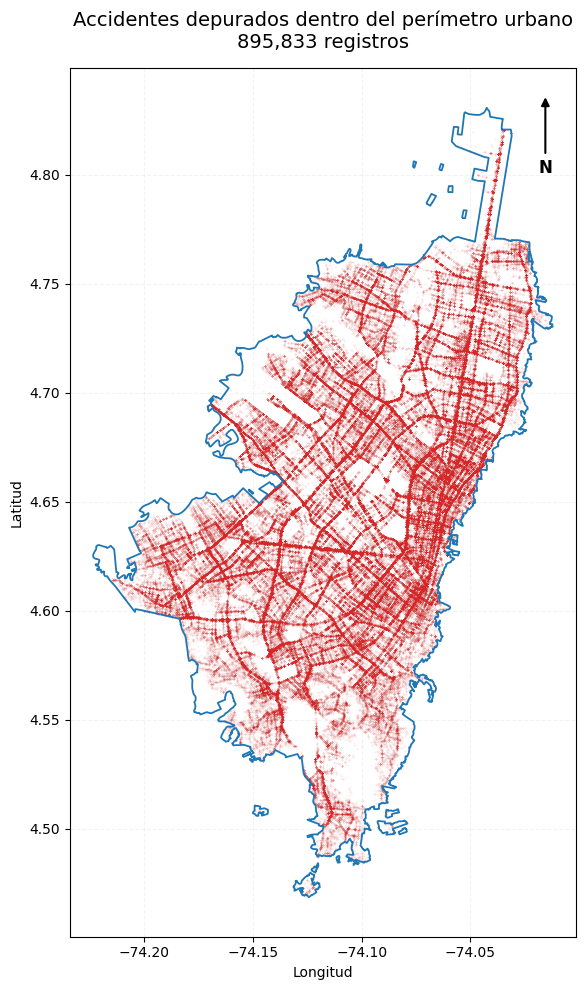

In [73]:
# Visualización de los puntos de accidentes depurados
puntos_depurados = puntos.loc[a['REGISTRO_UTILIZABLE']]

fig, ax = plt.subplots(figsize=(9, 10))

# Puntos de accidentes
puntos_depurados.plot(
    ax=ax,
    color='#d62728',
    markersize=0.08,
    alpha=0.06,
    rasterized=True,
    zorder=1
)

# Perímetro urbano encima de los puntos
perimetro_urbano.boundary.plot(
    ax=ax,
    color='#1f77b4',
    linewidth=1.3,
    zorder=2
)

ax.set_title(
    f'Accidentes depurados dentro del perímetro urbano\n'
    f'{len(puntos_depurados):,} registros',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

ax.annotate(
    'N',
    xy=(0.94, 0.97),
    xytext=(0.94, 0.88),
    xycoords='axes fraction',
    ha='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=1.5,
        color='black'
    )
)

ax.grid(alpha=0.15, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


La visualización permite comprobar que los accidentes depurados siguen una distribución espacial coherente con la malla vial de Bogotá. Los puntos se concentran sobre los principales corredores y en las zonas urbanas con mayor intensidad de circulación, mientras que en los bordes del perímetro la densidad disminuye. También se observa que los registros permanecen dentro del límite urbano utilizado en el proyecto, lo que confirma que la validación espacial fue consistente. Esta gráfica no muestra niveles de riesgo todavía, pero sí sirve para verificar que la base final conserva una cobertura espacial amplia y realista para el análisis posterior.

## 3. Validación de relaciones entre tablas de la BD original

En esta etapa se revisan dos aspectos por separado. Primero, la **integridad relacional**, para verificar que las llaves de las tablas secundarias tengan correspondencia con un registro en la tabla `ACCIDENTE` original. Después, se revisa el **impacto de la depuración**, identificando qué registros siguen asociados a accidentes utilizables para PrediRuta. Esta separación evita considerar como un error de relación aquellos casos que simplemente quedan por fuera del periodo o del perímetro definidos para el proyecto.

In [74]:
# Análisis de integridad relacional y cobertura de relaciones entre tablas
formularios_originales = set(a['FORMULARIO'].dropna())
accidente_ids_originales = set(a['ACCIDENTE_ID'].dropna())
formularios = set(a.loc[a['REGISTRO_UTILIZABLE'], 'FORMULARIO'].dropna())
accidente_ids = set(a.loc[a['REGISTRO_UTILIZABLE'], 'ACCIDENTE_ID'].dropna())
map_formulario = (
    a.loc[a['REGISTRO_UTILIZABLE'], ['FORMULARIO', 'ACCIDENTE_ID']]
    .drop_duplicates('FORMULARIO')
    .set_index('FORMULARIO')['ACCIDENTE_ID']
)

# Objetos para almacenar los resultados de integridad relacional y cobertura de relaciones
integridad_relacional = []
impacto_depuracion_relaciones = []

# Función para revisar la relación entre tablas y generar métricas de integridad y cobertura
def revisar_relacion(nombre, columna, llaves_originales, llaves_utilizables):
    d = leer(nombre, [columna])
    llave = texto(d[columna])
    con_llave = llave.notna()
    relacion_original = con_llave & llave.isin(llaves_originales)
    relacion_utilizable = con_llave & llave.isin(llaves_utilizables)
    huerfana = con_llave & ~relacion_original
    fuera_alcance = relacion_original & ~relacion_utilizable

    denominador_integridad = int(con_llave.sum())
    porcentaje_integridad = (
        relacion_original.sum() / denominador_integridad * 100
        if denominador_integridad else 0
    )
    cobertura = llave[relacion_utilizable].nunique()
    total_utilizables = len(llaves_utilizables)

    integridad_relacional.append([
        nombre, len(d), int((~con_llave).sum()), int(relacion_original.sum()),
        int(huerfana.sum()), round(porcentaje_integridad, 2),
    ])
    impacto_depuracion_relaciones.append([
        nombre, int(relacion_utilizable.sum()), int(fuera_alcance.sum()),
        round(relacion_utilizable.mean() * 100, 2), int(cobertura),
        round(cobertura / total_utilizables * 100, 2) if total_utilizables else 0,
    ])

# Revisión de relaciones entre tablas y generación de métricas de integridad y cobertura
for nombre in ['ACTOR_VIAL', 'LESIONADO', 'MUERTO', 'VEHICULO', 'CAUSA']:
    revisar_relacion(nombre, 'FORMULARIO', formularios_originales, formularios)

revisar_relacion('VIA', 'CODIGO_ACCIDENTE', accidente_ids_originales, accidente_ids)

# Generación de reportes de integridad relacional y cobertura de relaciones
reporte_integridad = pd.DataFrame(integridad_relacional, columns=[
    'tabla', 'filas_originales', 'llave_nula', 'relacion_valida_original',
    'llave_huerfana', 'porcentaje_integridad',
])
reporte_impacto_relaciones = pd.DataFrame(impacto_depuracion_relaciones, columns=[
    'tabla', 'filas_asociadas_a_accidentes_utilizables',
    'filas_asociadas_a_accidentes_fuera_alcance', 'porcentaje_conservado',
    'accidentes_utilizables_cubiertos', 'porcentaje_cobertura_accidentes',
])


La primera tabla permite revisar si existen llaves nulas o registros sin correspondencia con `ACCIDENTE` en la base original. La segunda muestra el efecto de la depuración aplicada sobre `ACCIDENTE`, diferenciando los registros que quedan fuera del alcance de aquellos que presentan un problema real de relación. Finalmente, la cobertura permite identificar qué tan completa es la información disponible en cada tabla temática para los accidentes utilizables en PrediRuta.

In [75]:
display(reporte_integridad.sort_values('porcentaje_integridad', ascending=False))
display(reporte_impacto_relaciones.sort_values('porcentaje_conservado', ascending=False))

,tabla,filas_originales,llave_nula,relacion_valida_original,llave_huerfana,porcentaje_integridad
1,LESIONADO,481423,0,481423,0,100.00
2,MUERTO,15890,0,15890,0,100.00
4,CAUSA,1870450,0,1870450,0,100.00
3,VEHICULO,2808440,0,1687048,1121392,60.07
0,ACTOR_VIAL,3273697,0,1948046,1325651,59.51
5,VIA,965149,0,0,965149,0.00


,tabla,filas_asociadas_a_accidentes_utilizables,filas_asociadas_a_accidentes_fuera_alcance,porcentaje_conservado,accidentes_utilizables_cubiertos,porcentaje_cobertura_accidentes
4,CAUSA,1853460,16990,99.09,875847,97.77
1,LESIONADO,475752,5671,98.82,328932,36.72
2,MUERTO,15614,276,98.26,15173,1.69
3,VEHICULO,1671090,15958,59.50,895099,99.92
0,ACTOR_VIAL,1928955,19091,58.92,895080,99.92
5,VIA,0,0,0.00,0,0.00


La revisión muestra que `LESIONADO`, `MUERTO` y `CAUSA` mantienen relaciones consistentes con la tabla `ACCIDENTE`. En cambio, `VIA`, `VEHICULO` y `ACTOR_VIAL` presentan una cantidad importante de registros cuya llave no tiene correspondencia en la tabla original de accidentes.

Al comparar con los accidentes utilizables para PrediRuta, el comportamiento se mantiene prácticamente igual. Esto indica que la mayor pérdida en estas tres tablas no se genera por los criterios de depuración del proyecto, sino que ya viene desde las relaciones presentes en la fuente original.

## 4. Tabla `VIA` depurada: selección de la vía principal

La tabla `VIA` puede tener varios registros asociados a un mismo accidente. Para construir una sola fila por evento, primero se conservan únicamente las vías relacionadas con accidentes utilizables y luego se aplica una regla de selección. Se prioriza la vía identificada como principal, después el registro con mayor cantidad de información disponible y, en caso de empate, el identificador de origen. Con esto se obtiene una única vía representativa para cada accidente.

`CODIGO_VIA` se excluye porque funciona como identificador del registro de origen y no como un catálogo reutilizable de vías; `ACCIDENTE_ID` ya garantiza la identificación y relación de cada fila. `VISIBILIDAD_VIA` también se retira porque no aporta una variable diferenciadora necesaria para el alcance analítico de PrediRuta. Ninguna de las dos columnas participa en la selección de la vía representativa.


In [76]:
# Columnas relevantes para la tabla VIA y depuración de registros relacionados con accidentes utilizables
cols_via = ['OBJECTID','CODIGO_ACCIDENTE','ES_PRINCIPAL','GEOMETRICAA','GEOMETRICAB',
            'GEOMETRICAC','UTILIZACION','CALZADAS','CARRILES','SUPERFICIE_RODADURA','ESTADO','CONDICIONES',
            'ILUMINACION_ARTIFICIAL','SEMAFORO']

# Lectura y depuración de la tabla VIA
via = leer('VIA', cols_via)
via['ACCIDENTE_ID'] = pd.to_numeric(
    texto(via['CODIGO_ACCIDENTE']), errors='coerce'
).astype('Int32')
via = via[via['ACCIDENTE_ID'].isin(accidente_ids)].copy()
via_relacionada = via.copy()

# Creación de columnas adicionales para priorizar registros de la tabla VIA
via['PRIORIDAD'] = pd.to_numeric(via['ES_PRINCIPAL'], errors='coerce').fillna(99)
via['COMPLETITUD'] = via[cols_via[2:]].notna().sum(axis=1)
via = (via.sort_values(['ACCIDENTE_ID','PRIORIDAD','COMPLETITUD','OBJECTID'], ascending=[True,True,False,True])
          .drop_duplicates('ACCIDENTE_ID'))

# Renombramiento de columnas y selección de columnas finales para la tabla VIA
via_final = via.rename(columns={
    'GEOMETRICAA':'GEOMETRIA_PLANTA','GEOMETRICAB':'GEOMETRIA_TERRENO','GEOMETRICAC':'GEOMETRIA_SECCION',
    'UTILIZACION':'SENTIDO_VIA','CALZADAS':'N_CALZADAS','CARRILES':'N_CARRILES','ESTADO':'ESTADO_VIA',
    'CONDICIONES':'CONDICION_VIA'
})[['ACCIDENTE_ID','GEOMETRIA_PLANTA','GEOMETRIA_TERRENO','GEOMETRIA_SECCION','SENTIDO_VIA','N_CALZADAS','N_CARRILES','SUPERFICIE_RODADURA','ESTADO_VIA','CONDICION_VIA','ILUMINACION_ARTIFICIAL','SEMAFORO']]


In [77]:
# Resumen de la depuración de registros de la tabla VIA y su relación con la tabla ACCIDENTE
resultado_via = pd.DataFrame([
    ['Filas relacionadas con accidentes utilizables', len(via_relacionada)],
    ['Vías principales conservadas', len(via_final)],
    ['Filas de vías retiradas', len(via_relacionada) - len(via_final)],
    ['Accidentes sin información de vía', len(accidente_ids) - len(via_final)],
    ['Accidentes que tenían más de una vía', via_relacionada.groupby('ACCIDENTE_ID').size().gt(1).sum()],
], columns=['resultado', 'cantidad'])

display(resultado_via)

display(via_final.head())


,resultado,cantidad
0,Filas relacionadas con accidentes utilizables,603625
1,Vías principales conservadas,488662
2,Filas de vías retiradas,114963
3,Accidentes sin información de vía,407171
4,Accidentes que tenían más de una vía,113791


,ACCIDENTE_ID,GEOMETRIA_PLANTA,GEOMETRIA_TERRENO,GEOMETRIA_SECCION,SENTIDO_VIA,N_CALZADAS,N_CARRILES,SUPERFICIE_RODADURA,ESTADO_VIA,CONDICION_VIA,ILUMINACION_ARTIFICIAL,SEMAFORO
0,10530788,RECTA,PLANO,CON ANDEN,DOBLE SENTIDO,1.0,1.0,ASFALTO,BUENO,SECA,SIN,NO
449,10530789,RECTA,PLANO,CON BERMA,UN SENTIDO,1.0,3.0,ASFALTO,BUENO,SECA,CON,NO
113,10530790,RECTA,PLANO,CON BERMA,UN SENTIDO,1.0,2.0,ASFALTO,BUENO,SECA,CON,NO
447,10530791,RECTA,PLANO,CON ANDEN,UN SENTIDO,3.0,3.0,ASFALTO,BUENO,SECA,CON,NO
1,10530792,RECTA,PLANO,CON BERMA,UN SENTIDO,1.0,2.0,CONCRETO,BUENO,SECA,CON,SI


La depuración permite consolidar los casos donde un accidente tenía más de un registro en `VIA` y conservar una sola vía representativa por evento. Sin embargo, también se observa que una parte importante de los accidentes utilizables no cuenta con información vial asociada. Por esta razón, las variables de `VIA` podrán incorporarse al modelo, pero su nivel de cobertura deberá tenerse en cuenta durante la etapa de análisis y selección de variables.

## 5. Tabla `ACTOR_VIAL` depurada y contraste con `LESIONADO` y `MUERTO`

En `ACTOR_VIAL` se normalizan las llaves, se conservan únicamente los actores asociados a accidentes utilizables y se eliminan duplicados por accidente y código de actor. Las tablas `LESIONADO` y `MUERTO` se utilizan como apoyo para validar la cobertura de la información, pero no se mantienen como tablas finales porque estas condiciones pueden representarse desde `ACTOR_VIAL`.

Estas variables corresponden a consecuencias del accidente, por lo que se reservan para los análisis de severidad y no se utilizan como variables predictoras de la ocurrencia.

El código original del accidentado se conserva únicamente como llave técnica y se renombra `ACTOR_ID`. Como todos sus valores son numéricos y únicos, se almacena como entero para reducir espacio; no se utiliza como predictor.

In [78]:
# Limpieza y depuración de la tabla ACTOR_VIAL

# Selección de columnas relevantes y depuración de registros relacionados con accidentes utilizables
actor = leer('ACTOR_VIAL', ['FORMULARIO','CODIGO_ACCIDENTADO','CODIGO_VEHICULO',
                            'CONDICION','ESTADO','GENERO','EDAD'])
actor['FORMULARIO'] = texto(actor['FORMULARIO'])
actor['CODIGO_ACCIDENTADO'] = texto(actor['CODIGO_ACCIDENTADO'])

# Filtrado de registros de ACTOR_VIAL que están relacionados con formularios utilizables y que tienen un código de accidentado no nulo
actor = actor[actor['FORMULARIO'].isin(formularios) & actor['CODIGO_ACCIDENTADO'].notna()].copy()
actor['ACCIDENTE_ID'] = actor['FORMULARIO'].map(map_formulario).astype('Int32')

# Normalización de columnas de texto y conversión de tipos de datos
actor['ACTOR_ID'] = pd.to_numeric(actor['CODIGO_ACCIDENTADO'], errors='raise').astype('int32')
actor['CODIGO_VEHICULO'] = pd.to_numeric(
    actor['CODIGO_VEHICULO'], errors='coerce'
).astype('Int8')
actor['VEHICULO_ID'] = (
    actor['ACCIDENTE_ID'].astype('Int64') * 100
    + actor['CODIGO_VEHICULO'].astype('Int64') + 1
).astype('Int32')

# Creación de la tabla final de ACTOR_VIAL con registros únicos por accidente y accidentado
actor_final = (actor.sort_values(['ACCIDENTE_ID','ACTOR_ID'])
    .drop_duplicates(['ACCIDENTE_ID','ACTOR_ID'])
    [['ACCIDENTE_ID','ACTOR_ID','VEHICULO_ID','CONDICION','ESTADO','GENERO','EDAD']])


In [79]:
# Resumen de la depuración de registros de la tabla ACTOR_VIAL y su relación con la tabla ACCIDENTE
resultado_actores = pd.DataFrame([
    ['Actores relacionados con accidentes utilizables', len(actor)],
    ['Actores conservados', len(actor_final)],
    ['Registros duplicados retirados', len(actor) - len(actor_final)],
    ['Accidentes con información de actores', actor_final['ACCIDENTE_ID'].nunique()],
], columns=['resultado', 'cantidad'])

display(resultado_actores)

# LESIONADO y MUERTO se revisan como fuentes de contraste, no se exportan al BD final
contraste_actores = []
for nombre in ['LESIONADO', 'MUERTO']:
    d = leer(nombre, ['FORMULARIO', 'CODIGO_ACCIDENTADO'])
    d['FORMULARIO'] = texto(d['FORMULARIO'])
    relacionadas = d['FORMULARIO'].isin(formularios).sum()
    contraste_actores.append([nombre, len(d), relacionadas, len(d) - relacionadas])
    

display(pd.DataFrame(
    contraste_actores,
    columns=['fuente', 'filas_originales', 'relacionadas', 'sin_accidente_valido'],
))

display(actor_final.head())


,resultado,cantidad
0,Actores relacionados con accidentes utilizables,1928580
1,Actores conservados,1928580
2,Registros duplicados retirados,0
3,Accidentes con información de actores,894705


,fuente,filas_originales,relacionadas,sin_accidente_valido
0,LESIONADO,481423,475752,5671
1,MUERTO,15890,15614,276


,ACCIDENTE_ID,ACTOR_ID,VEHICULO_ID,CONDICION,ESTADO,GENERO,EDAD
116745,104,19279,10402,CONDUCTOR,ILESO,FEMENINO,28.0
128788,104,19280,10403,CONDUCTOR,ILESO,MASCULINO,41.0
130772,105,19281,10502,CONDUCTOR,ILESO,MASCULINO,56.0
115830,105,19282,10503,CONDUCTOR,ILESO,MASCULINO,53.0
110421,106,19283,10602,CONDUCTOR,ILESO,MASCULINO,23.0


La tabla `ACTOR_VIAL` conserva de forma completa los registros asociados a los accidentes utilizables y no presenta duplicados bajo la llave definida. Además, la cobertura sobre los accidentes es alta, por lo que esta tabla puede utilizarse como fuente principal para caracterizar a los involucrados.

El contraste con `LESIONADO` y `MUERTO` muestra que la mayor parte de estos registros también tiene correspondencia con accidentes válidos. Esto respalda el uso de `ACTOR_VIAL` como tabla final para representar las consecuencias sobre las personas, dejando las otras dos fuentes únicamente como apoyo de validación.

## 6. Depuración de `VEHICULO`

En la tabla `VEHICULO` se conservan únicamente los registros relacionados con accidentes utilizables. Se normalizan el formulario y el código del vehículo, se eliminan los registros que no cuentan con una llave válida y se consolida una sola fila por accidente y vehículo. Con esto se obtiene una tabla más limpia para analizar posteriormente las características de los vehículos involucrados.

El código original del vehículo no se exporta ni se usa como predictor. Durante la limpieza se combina con `ACCIDENTE_ID` para generar un `VEHICULO_ID` entero y único, utilizado para relacionar vehículos, actores y causas sin conservar llaves compuestas o códigos técnicos de la fuente.

In [80]:
# Limpieza y depuración de la tabla VEHICULO

# Selección de columnas relevantes y depuración de registros relacionados con accidentes utilizables
veh = leer('VEHICULO', ['FORMULARIO','CODIGO_VEHICULO','CLASE','SERVICIO'])

# Normalización de columnas de texto y conversión de tipos de datos
veh['FORMULARIO'] = texto(veh['FORMULARIO'])
veh['CODIGO_VEHICULO'] = pd.to_numeric(
    veh['CODIGO_VEHICULO'], errors='coerce'
).astype('Int8')
veh = veh[veh['FORMULARIO'].isin(formularios) & veh['CODIGO_VEHICULO'].notna()].copy()
veh['ACCIDENTE_ID'] = veh['FORMULARIO'].map(map_formulario).astype('Int32')
veh['VEHICULO_ID'] = (
    veh['ACCIDENTE_ID'].astype('int64') * 100
    + veh['CODIGO_VEHICULO'].astype('int64') + 1
).astype('int32')

# Creación de la tabla final de VEHICULO con registros únicos por accidente y vehículo
vehiculo_final = (veh.sort_values(['ACCIDENTE_ID','CODIGO_VEHICULO'])
    .drop_duplicates(['ACCIDENTE_ID','CODIGO_VEHICULO'])
    [['ACCIDENTE_ID','VEHICULO_ID','CLASE','SERVICIO']])


In [81]:
# Resumen de la depuración de registros de la tabla VEHICULO y su relación con la tabla ACCIDENTE
resultado_vehiculo = pd.DataFrame([
    ['Vehículos relacionados con accidentes utilizables', len(veh)],
    ['Vehículos conservados', len(vehiculo_final)],
    ['Duplicados retirados', len(veh) - len(vehiculo_final)],
    ['Accidentes con vehículos', vehiculo_final['ACCIDENTE_ID'].nunique()],
], columns=['resultado', 'cantidad'])

display(resultado_vehiculo)

display(vehiculo_final.head())

,resultado,cantidad
0,Vehículos relacionados con accidentes utilizables,1670699
1,Vehículos conservados,1670699
2,Duplicados retirados,0
3,Accidentes con vehículos,894708


,ACCIDENTE_ID,VEHICULO_ID,CLASE,SERVICIO
102488,104,10402,AUTOMOVIL,PARTICULAR
103697,104,10403,BUS,PUBLICO
100957,105,10502,BUSETA,PUBLICO
83533,105,10503,AUTOMOVIL,PARTICULAR
88504,106,10602,MICROBUS,PUBLICO


La depuración muestra que `VEHICULO` mantiene una relación amplia con los accidentes utilizables y no presenta duplicados bajo la llave definida. Esto permite conservar el detalle de los vehículos involucrados sin necesidad de aplicar consolidaciones adicionales. La cobertura obtenida es suficiente para considerar sus variables en los análisis posteriores del proyecto.

## 7. Depuración de `CAUSA`

En la tabla `CAUSA` se conservan únicamente los registros asociados a accidentes utilizables y se eliminan repeticiones de una misma combinación entre accidente, vehículo y causa. A cada fila se le asigna un `CAUSA_ID` entero y la relación opcional con el vehículo se conserva mediante `VEHICULO_ID`. Como esta información se registra después de ocurrido el accidente, se utiliza principalmente para análisis descriptivos y de severidad, pero no como una variable disponible al momento de estimar el riesgo futuro de una ruta.

In [82]:
# Limpieza y depuración de la tabla CAUSA

# Selección de columnas relevantes y depuración de registros relacionados con accidentes utilizables
causa = leer('CAUSA', ['FORMULARIO','CODIGO_VEHICULO','CODIGO_CAUSA','NOMBRE','TIPO'])

# Normalización de columnas de texto y conversión de tipos de datos
causa['FORMULARIO'] = texto(causa['FORMULARIO'])
causa = causa[causa['FORMULARIO'].isin(formularios)].copy()
causa['ACCIDENTE_ID'] = causa['FORMULARIO'].map(map_formulario).astype('Int32')
causa['CODIGO_VEHICULO'] = pd.to_numeric(
    causa['CODIGO_VEHICULO'], errors='coerce'
).astype('Int8')
vehiculo_id_causa = (
    causa['ACCIDENTE_ID'].astype('Int64') * 100
    + causa['CODIGO_VEHICULO'].astype('Int64') + 1
)
ids_vehiculo_validos = set(vehiculo_final['VEHICULO_ID'])
causa['VEHICULO_ID'] = vehiculo_id_causa.where(
    vehiculo_id_causa.isin(ids_vehiculo_validos)
).astype('Int32')
causa['CODIGO_CAUSA'] = texto(causa['CODIGO_CAUSA'])

# Creación de la tabla final de CAUSA con registros únicos por accidente, vehículo y causa
causa_final = (causa.dropna(subset=['ACCIDENTE_ID','CODIGO_CAUSA'])
    .drop_duplicates(['ACCIDENTE_ID','CODIGO_VEHICULO','CODIGO_CAUSA'])
    .rename(columns={'DESCRIPCION2':'DESCRIPCION'})
    [['ACCIDENTE_ID','VEHICULO_ID','CODIGO_CAUSA','NOMBRE','TIPO']]
    .sort_values(['ACCIDENTE_ID','VEHICULO_ID','CODIGO_CAUSA'])
    .reset_index(drop=True))
causa_final.insert(0, 'CAUSA_ID', np.arange(1, len(causa_final) + 1, dtype=np.int32))


In [83]:
resultado_causa = pd.DataFrame([
    ['Causas relacionadas con accidentes utilizables', len(causa)],
    ['Causas conservadas', len(causa_final)],
    ['Registros retirados por duplicidad o falta de código', len(causa) - len(causa_final)],
    ['Accidentes con causas', causa_final['ACCIDENTE_ID'].nunique()],
], columns=['resultado', 'cantidad'])
display(resultado_causa)
display(causa_final.head())


,resultado,cantidad
0,Causas relacionadas con accidentes utilizables,1853460
1,Causas conservadas,1284682
2,Registros retirados por duplicidad o falta de ...,568778
3,Accidentes con causas,875847


,CAUSA_ID,ACCIDENTE_ID,VEHICULO_ID,CODIGO_CAUSA,NOMBRE,TIPO
0,1,104,10402,157,OTRA,CG
1,2,105,10502,102,ADELANTAR POR LA DERECHA,CG
2,3,106,10602,101,ADELANTAR EN CURVA,CG
3,4,107,10702,112,DESOBEDECER SEÑALES,CG
4,5,108,10802,112,DESOBEDECER SEÑALES,CG


La depuración de `CAUSA` elimina una cantidad importante de registros repetidos o sin código identificable, pero mantiene una cobertura amplia sobre los accidentes utilizables. Esto permite conservar una versión más consistente de la tabla sin perder de forma significativa la información disponible para los análisis descriptivos y de severidad.

## 8. Construcción de CLIMA con ERA5 y ECMWF IFS

Open-Meteo permite consultar diferentes productos meteorológicos históricos. Para PrediRuta se utiliza **ERA5 antes de 2017** y **ECMWF IFS desde 2017**. ERA5 ofrece información horaria sobre una cuadrícula regular de `0,25°`, equivalente aproximadamente a `25–28 km` en Bogotá. Desde 2017 se utiliza ECMWF IFS, que cuenta con una resolución aproximada de `9 km` y permite trabajar con un mayor detalle espacial.

La combinación de ambos modelos permite mantener la cobertura histórica y utilizar las variables meteorológicas requeridas para el proyecto, como temperatura, humedad relativa, sensación térmica, precipitación, lluvia, nubosidad, presión y viento.

Para ERA5, los accidentes se asocian a los puntos de su cuadrícula regular de `0,25°`. En IFS no se construye una cuadrícula artificial: se realizan consultas de prueba sobre Bogotá, se identifican los nodos meteorológicos que realmente devuelve Open-Meteo y cada accidente se asigna al nodo más cercano.

La información también se relaciona por hora. Por ejemplo, un accidente ocurrido a las `11:50` se asocia con la observación de las `12:00`. Los accidentes que coinciden en modelo, nodo y hora comparten el mismo `CLIMA_ID`, evitando almacenar observaciones meteorológicas repetidas.

Fuente: https://open-meteo.com/

### Configuración y funciones para consultar Open-Meteo

En esta celda se configura el uso de ERA5 antes de `2017-01-01` y ECMWF IFS a partir de esa fecha, junto con las variables meteorológicas que se van a consultar. También se definen las funciones encargadas de realizar las descargas y validar las respuestas de la API.

Para identificar los nodos reales de IFS se utiliza una malla de puntos sonda separados `0,02°`. Esta exploración se realiza una sola vez sobre Bogotá y los nodos encontrados se almacenan en caché para reutilizarlos en las consultas posteriores.

Las respuestas climáticas solo se conservan cuando incluyen todas las variables requeridas y ninguna de ellas se encuentra completamente vacía.

In [84]:
# Descarga de datos climáticos históricos para los accidentes
URL_OPEN_METEO = 'https://archive-api.open-meteo.com/v1/archive' # URL de la API de Open-Meteo para acceder a datos climáticos históricos
ZONA_HORARIA = 'America/Bogota'
CORTE_ECMWF_IFS = pd.Timestamp('2017-01-01')
DIAS_ANTICIPACION = 5 # Número de días de anticipación para la descarga de datos climáticos históricos
RESOLUCION_ERA5 = 0.25 # Resolución nominal de la grilla ERA5 en grados
RESOLUCION_NOMINAL_IFS_KM = 9 # Resolución nominal de la grilla ECMWF IFS en kilómetros
PASO_SONDA_GRADOS = 0.02 # Paso de sonda en grados para identificar nodos ECMWF IFS sobre Bogotá
FECHA_SONDA_IFS = pd.Timestamp('2020-01-01') # Fecha de referencia para la sonda de nodos ECMWF IFS
RUTA_NODOS_IFS = CACHE_CLIMA / 'nodos_ecmwf_ifs_bogota.csv' # Ruta para almacenar los nodos ECMWF IFS identificados sobre Bogotá
VARIABLES_CLIMA = [ # Lista de variables climáticas a descargar desde la API de Open-Meteo
    'temperature_2m','relative_humidity_2m','apparent_temperature',
    'precipitation','rain','cloud_cover','surface_pressure',
    'wind_speed_10m','wind_direction_10m',
]

In [85]:
# Nombre del archivo de caché según el modelo y el nodo climático
def nombre_cache_clima(latitud, longitud, modelo):
    precision = 2 if modelo == 'era5' else 5
    lat = f'{latitud:.{precision}f}'.replace('-', 'm')
    lon = f'{longitud:.{precision}f}'.replace('-', 'm')
    return CACHE_CLIMA / f'clima_{modelo}_{lat}_{lon}.csv'

# Consulta común a Open-Meteo con reintentos y espera cuando la API limita las solicitudes
def consultar_open_meteo(params, descripcion, intentos=6):
    for intento in range(intentos):
        try:
            respuesta = requests.get(URL_OPEN_METEO, params=params, timeout=120)
            if respuesta.status_code == 429:
                espera = int(respuesta.headers.get('Retry-After', min(30 * (intento + 1), 180)))
                time.sleep(espera)
                continue
            respuesta.raise_for_status()
            return respuesta.json()
        except requests.RequestException as exc:
            if intento == intentos - 1:
                raise RuntimeError(f'No fue posible consultar {descripcion}.') from exc
            time.sleep(min(5 * 2 ** intento, 120))

    raise RuntimeError(f'Open-Meteo mantuvo el límite de consultas para {descripcion}.')

# Identificación del nodo IFS que Open-Meteo asigna a una coordenada
def consultar_nodo_ifs(latitud, longitud):
    fecha = FECHA_SONDA_IFS.strftime('%Y-%m-%d')
    datos = consultar_open_meteo({
        'latitude': latitud,
        'longitude': longitud,
        'start_date': fecha,
        'end_date': fecha,
        'hourly': 'temperature_2m',
        'timezone': ZONA_HORARIA,
        'models': 'ecmwf_ifs',
        'cell_selection': 'nearest',
    }, f'el nodo IFS de ({latitud}, {longitud})')

    if datos.get('latitude') is None or datos.get('longitude') is None:
        raise ValueError('La respuesta no contiene las coordenadas del nodo meteorológico.')
    return {
        'LATITUD_NODO': round(float(datos['latitude']), 6),
        'LONGITUD_NODO': round(float(datos['longitude']), 6),
        'ELEVACION_NODO_M': datos.get('elevation'),
    }

# Descubrimiento de los nodos IFS que cubren el perímetro urbano de Bogotá
def descubrir_nodos_ifs(geometria_bogota):
    columnas = ['LATITUD_NODO', 'LONGITUD_NODO', 'ELEVACION_NODO_M']
    if RUTA_NODOS_IFS.exists():
        nodos = pd.read_csv(RUTA_NODOS_IFS)
        if set(columnas).issubset(nodos.columns) and not nodos.empty:
            return nodos[columnas].drop_duplicates(columnas[:2])

    min_lon, min_lat, max_lon, max_lat = geometria_bogota.bounds
    zona_sonda = geometria_bogota.buffer(PASO_SONDA_GRADOS)
    sondas = [
        (lat, lon)
        for lat in np.arange(min_lat, max_lat + PASO_SONDA_GRADOS, PASO_SONDA_GRADOS)
        for lon in np.arange(min_lon, max_lon + PASO_SONDA_GRADOS, PASO_SONDA_GRADOS)
        if Point(lon, lat).within(zona_sonda)
    ]

    resultados = []
    for numero, (lat, lon) in enumerate(sondas, 1):
        print(f'\rDescubriendo nodos IFS: {numero} / {len(sondas)}', end='', flush=True)
        resultados.append(consultar_nodo_ifs(lat, lon))
        time.sleep(random.uniform(0.5, 1.5))
    print()

    nodos = (pd.DataFrame(resultados, columns=columnas)
        .drop_duplicates(columnas[:2])
        .sort_values(columnas[:2])
        .reset_index(drop=True))
    if nodos.empty:
        raise ValueError('No se identificaron nodos de ECMWF IFS sobre Bogotá.')
    nodos.to_csv(RUTA_NODOS_IFS, index=False, encoding='utf-8-sig')
    return nodos

# Descarga y validación de una serie climática histórica
def descargar_clima(latitud, longitud, fecha_inicio, fecha_fin, modelo):
    datos = consultar_open_meteo({
        'latitude': latitud,
        'longitude': longitud,
        'start_date': pd.Timestamp(fecha_inicio).strftime('%Y-%m-%d'),
        'end_date': pd.Timestamp(fecha_fin).strftime('%Y-%m-%d'),
        'hourly': ','.join(VARIABLES_CLIMA),
        'timezone': ZONA_HORARIA,
        'models': modelo,
        'cell_selection': 'nearest',
    }, f'{modelo} para ({latitud}, {longitud})')

    bloque = pd.DataFrame(datos.get('hourly', {}))
    faltantes = ['time'] + [v for v in VARIABLES_CLIMA if v not in bloque.columns]
    faltantes = list(dict.fromkeys(v for v in faltantes if v not in bloque.columns))
    vacias = [v for v in VARIABLES_CLIMA if v in bloque and bloque[v].isna().all()]
    if faltantes or vacias:
        raise ValueError(f'Variables faltantes: {faltantes}; variables vacías: {vacias}')

    bloque['FECHA_HORA_CLIMA'] = pd.to_datetime(bloque.pop('time'), errors='coerce')
    bloque = bloque.assign(
        LATITUD_CELDA=latitud,
        LONGITUD_CELDA=longitud,
        LATITUD_MODELO=datos.get('latitude'),
        LONGITUD_MODELO=datos.get('longitude'),
        ELEVACION_MODELO_M=datos.get('elevation'),
        MODELO=modelo,
        FUENTE='Open-Meteo Historical Weather API',
    )
    return bloque

# Función para obtener datos climáticos históricos desde la caché o descargarlos si no existen
def obtener_cache_clima(latitud, longitud, inicio, fin, modelo):
    ruta = nombre_cache_clima(latitud, longitud, modelo)
    if ruta.exists():
        cache = pd.read_csv(ruta, encoding='utf-8-sig', low_memory=False)
        cache['FECHA_HORA_CLIMA'] = pd.to_datetime(cache['FECHA_HORA_CLIMA'], errors='coerce')
        cache_completo = (
            set(VARIABLES_CLIMA).issubset(cache.columns)
            and not cache[VARIABLES_CLIMA].isna().all().any()
            and 'MODELO' in cache.columns
            and cache['MODELO'].eq(modelo).all()
        )
        cubre_periodo = (
            cache['FECHA_HORA_CLIMA'].min() <= pd.Timestamp(inicio).normalize()
            and cache['FECHA_HORA_CLIMA'].max() >= pd.Timestamp(fin).normalize() + pd.Timedelta(hours=23)
        )
        if cache_completo and cubre_periodo:
            return cache

    cache = descargar_clima(latitud, longitud, inicio, fin, modelo)
    cache.to_csv(ruta, index=False, encoding='utf-8-sig')
    return cache


### Descarga y relación del clima con los accidentes

Primero se identifican y guardan los nodos de ECMWF IFS que cubren el perímetro urbano de Bogotá. A partir de 2017, cada accidente se asigna al nodo más cercano utilizando distancias en metros. Para los años anteriores se utiliza la cuadrícula regular de ERA5.

La información climática se descarga una sola vez por modelo y nodo para todo el periodo necesario. Después, cada accidente se relaciona con la observación horaria que le corresponde, evitando repetir consultas y almacenar información climática duplicada.

**1. Preparación de los accidentes para la relación climática**

Primero se identifican los nodos de ECMWF IFS disponibles sobre Bogotá y se toman únicamente los accidentes utilizables que cuentan con fecha, hora y ubicación válidas para relacionarlos con la información meteorológica.

Como ERA5 e IFS trabajan con información horaria, la hora de cada accidente se aproxima a la observación más cercana; cuando el evento ocurre desde el minuto 30, se asigna a la hora siguiente. Finalmente, cada registro se relaciona con ERA5 o ECMWF IFS según la fecha en la que ocurrió el accidente.

In [86]:
# Identificación de los nodos IFS que cubren el perímetro urbano de Bogotá
geometria_bogota = perimetro_urbano.to_crs(4326).geometry.union_all()
nodos_ifs = descubrir_nodos_ifs(geometria_bogota)

# Preparación de la tabla de accidentes para la descarga de datos climáticos históricos
fecha_maxima_disponible = pd.Timestamp.today().normalize() - pd.Timedelta(days=DIAS_ANTICIPACION)
eventos_clima = a.loc[
    a['REGISTRO_UTILIZABLE'] & a['FECHA_HORA'].le(fecha_maxima_disponible),
    ['ACCIDENTE_ID', 'FECHA_HORA', 'LATITUD', 'LONGITUD'],
].copy()

# Asignación del modelo climático según la fecha del accidente y creación de la columna de fecha y hora del clima
eventos_clima['FECHA_HORA_CLIMA'] = (
    eventos_clima['FECHA_HORA'] + pd.Timedelta(minutes=30)
).dt.floor('h')
eventos_clima['MODELO'] = np.where(
    eventos_clima['FECHA_HORA_CLIMA'].ge(CORTE_ECMWF_IFS),
    'ecmwf_ifs',
    'era5',
)
eventos_clima[['LATITUD_CELDA', 'LONGITUD_CELDA', 'DISTANCIA_NODO_M']] = np.nan

display(eventos_clima['MODELO'].value_counts().rename_axis('modelo').reset_index(name='accidentes'))


,modelo,accidentes
0,era5,558303
1,ecmwf_ifs,337530


**2. Asignación de los eventos históricos a ERA5**

Los accidentes anteriores a 2017 se relacionan con la celda ERA5 más cercana. Como este modelo trabaja con una cuadrícula regular de `0,25°`, la latitud y la longitud se aproximan a esa resolución para identificar el punto meteorológico correspondiente.

La coordenada original del accidente se conserva sin cambios; únicamente se agregan las coordenadas de la celda ERA5 utilizada para relacionar posteriormente la información climática.

In [87]:
# Ajuste de coordenadas a la grilla ERA5 para los accidentes que requieren este modelo
es_era5 = eventos_clima['MODELO'].eq('era5')
eventos_clima.loc[es_era5, 'LATITUD_CELDA'] = (
    np.floor(eventos_clima.loc[es_era5, 'LATITUD'] / RESOLUCION_ERA5 + 0.5)
    * RESOLUCION_ERA5
).round(2)
eventos_clima.loc[es_era5, 'LONGITUD_CELDA'] = (
    np.floor(eventos_clima.loc[es_era5, 'LONGITUD'] / RESOLUCION_ERA5 + 0.5)
    * RESOLUCION_ERA5
).round(2)


**3. Asignación de los eventos recientes a ECMWF IFS**

Para los accidentes desde 2017 no se construye una cuadrícula por redondeo. Cada evento se relaciona con el nodo real de ECMWF IFS más cercano entre los identificados previamente con Open-Meteo.

La comparación se realiza en un sistema de coordenadas métricas para calcular la distancia en metros entre el accidente y el nodo asignado. Esta distancia también se conserva para revisar qué tan cercana es la aproximación espacial utilizada.

In [88]:
# Ajuste de coordenadas a la grilla ECMWF IFS para los accidentes que requieren este modelo
es_ifs = eventos_clima['MODELO'].eq('ecmwf_ifs')
puntos_ifs = gpd.GeoDataFrame(
    eventos_clima.loc[es_ifs].assign(INDICE_EVENTO=lambda x: x.index),
    geometry=gpd.points_from_xy(
        eventos_clima.loc[es_ifs, 'LONGITUD'],
        eventos_clima.loc[es_ifs, 'LATITUD'],
    ),
    crs=4326,
).to_crs(3116)

# Creación de un GeoDataFrame con los nodos ECMWF IFS y transformación a la proyección local
nodos_ifs_gdf = gpd.GeoDataFrame(
    nodos_ifs.copy(),
    geometry=gpd.points_from_xy(nodos_ifs['LONGITUD_NODO'], nodos_ifs['LATITUD_NODO']),
    crs=4326,
).to_crs(3116)

# Asignación del nodo IFS más cercano a cada accidente que requiere este modelo
asignacion_ifs = (gpd.sjoin_nearest(
    puntos_ifs,
    nodos_ifs_gdf[['LATITUD_NODO', 'LONGITUD_NODO', 'geometry']],
    how='left',
    distance_col='DISTANCIA_NODO_M_ASIGNADA',
)
    .sort_values('DISTANCIA_NODO_M_ASIGNADA')
    .drop_duplicates('INDICE_EVENTO')
    .set_index('INDICE_EVENTO'))

# Actualización de las coordenadas de celda y la distancia al nodo IFS asignado en la tabla de eventos climáticos
eventos_clima.loc[asignacion_ifs.index, 'LATITUD_CELDA'] = asignacion_ifs['LATITUD_NODO']
eventos_clima.loc[asignacion_ifs.index, 'LONGITUD_CELDA'] = asignacion_ifs['LONGITUD_NODO']
eventos_clima.loc[asignacion_ifs.index, 'DISTANCIA_NODO_M'] = asignacion_ifs['DISTANCIA_NODO_M_ASIGNADA']


**4. Identificación de las observaciones climáticas requeridas**

Cada observación climática se define por el modelo, el nodo o celda meteorológica y la hora. A partir de esta combinación se construye `CLIMA_ID`, que permite reutilizar una misma observación cuando varios accidentes coinciden en el mismo punto meteorológico y periodo horario.

Con esto se evitan consultas y registros duplicados, manteniendo una relación única entre cada accidente y la información climática que le corresponde.

In [89]:
# Catálogo ordenado de observaciones climáticas y asignación de un ID entero compacto.
COLUMNAS_CLAVE_CLIMA = [
    'MODELO', 'LATITUD_CELDA', 'LONGITUD_CELDA', 'FECHA_HORA_CLIMA'
]
claves_clima = (
    eventos_clima[COLUMNAS_CLAVE_CLIMA]
    .drop_duplicates()
    .sort_values(COLUMNAS_CLAVE_CLIMA)
    .reset_index(drop=True)
)
claves_clima['CLIMA_ID'] = np.arange(1, len(claves_clima) + 1, dtype=np.int32)
eventos_clima = eventos_clima.merge(
    claves_clima,
    on=COLUMNAS_CLAVE_CLIMA,
    how='left',
    validate='m:1',
)

# El merge reconstruye el índice; regenerar las máscaras para mantenerlas alineadas.
es_era5 = eventos_clima['MODELO'].eq('era5')
es_ifs = eventos_clima['MODELO'].eq('ecmwf_ifs')

# Resumen de la asignación de modelos y c
resumen_asignacion = eventos_clima.groupby('MODELO').agg(
    accidentes=('ACCIDENTE_ID', 'size'),
    celdas_o_nodos=('CLIMA_ID', lambda s: eventos_clima.loc[s.index, ['LATITUD_CELDA', 'LONGITUD_CELDA']].drop_duplicates().shape[0]),
    observaciones_climaticas=('CLIMA_ID', 'nunique'),
).reset_index()

display(resumen_asignacion)

,MODELO,accidentes,celdas_o_nodos,observaciones_climaticas
0,ecmwf_ifs,337530,15,170040
1,era5,558303,4,155274


**5. Preparación de las descargas por modelo y ubicación**

Los accidentes se agrupan según el modelo y la ubicación meteorológica asignada. Para cada grupo se identifica únicamente el rango de fechas que necesita ser consultado.

De esta forma se descarga una sola serie climática por nodo o celda, se guarda en caché y luego se reutiliza para todos los accidentes asociados a esa misma ubicación.

In [90]:
# Creación de grupos de eventos climáticos para mejorar la descarga de datos históricos
grupos_clima = list(eventos_clima.groupby(
    ['LATITUD_CELDA', 'LONGITUD_CELDA', 'MODELO'],
    sort=True,
))
total_grupos = len(grupos_clima)
bloques_clima = []

print(f'Grupos climáticos por consultar: {total_grupos}')

Grupos climáticos por consultar: 19


**6. Descarga de las series climáticas**

En esta etapa se realizan las consultas históricas completas para cada modelo y ubicación meteorológica. El proceso muestra el avance de las descargas y aplica una pequeña espera entre solicitudes para evitar concentrarlas en un mismo momento.

Cuando la información de un nodo o celda ya fue descargada para el periodo requerido, se reutiliza el archivo almacenado en caché y no se vuelve a consultar la API.

In [91]:
# Descarga de datos climáticos históricos para cada grupo de eventos
for numero, ((lat, lon, modelo), grupo) in enumerate(grupos_clima, start=1):
    print(f'\r{numero} / {total_grupos}', end='', flush=True)
    inicio_grupo = grupo['FECHA_HORA_CLIMA'].min().normalize()
    fin_grupo = grupo['FECHA_HORA_CLIMA'].max().normalize()
    bloques_clima.append(obtener_cache_clima(lat, lon, inicio_grupo, fin_grupo, modelo))
    time.sleep(random.uniform(3, 10))

print()

if not bloques_clima:
    raise ValueError('No hay accidentes elegibles dentro del periodo climático disponible.')


19 / 19


**7. Unión del clima con los accidentes**

Las series climáticas descargadas se integran con los accidentes utilizando el modelo, la ubicación meteorológica y la hora asignada. La validación `m:1` asegura que cada accidente se relacione como máximo con una observación climática, aunque esa misma observación pueda ser compartida por varios accidentes ocurridos en el mismo nodo o celda y periodo horario.

In [92]:
# Concatenación de los bloques de datos climáticos descargados y fusión con la tabla de eventos climáticos
serie_clima = pd.concat(bloques_clima, ignore_index=True)
clima = eventos_clima.merge(
    serie_clima,
    on=['LATITUD_CELDA', 'LONGITUD_CELDA', 'MODELO', 'FECHA_HORA_CLIMA'],
    how='left',
    validate='m:1',
)

In [93]:
# Resumen de nodos meteorológicos utilizados
resumen_nodos = pd.DataFrame([
    {
        'modelo': 'ERA5',
        'resolucion_aprox': '25–28 km',
        'nodos_identificados': eventos_clima.loc[
            eventos_clima['MODELO'].eq('era5'), ['LATITUD_CELDA', 'LONGITUD_CELDA']
        ].drop_duplicates().shape[0],
        'nodos_utilizados': eventos_clima.loc[
            eventos_clima['MODELO'].eq('era5'), ['LATITUD_CELDA', 'LONGITUD_CELDA']
        ].drop_duplicates().shape[0]
    },
    {
        'modelo': 'ECMWF IFS',
        'resolucion_aprox': '9 km',
        'nodos_identificados': len(nodos_ifs),
        'nodos_utilizados': eventos_clima.loc[
            eventos_clima['MODELO'].eq('ecmwf_ifs'), ['LATITUD_CELDA', 'LONGITUD_CELDA']
        ].drop_duplicates().shape[0]
    }
])

display(resumen_nodos)

,modelo,resolucion_aprox,nodos_identificados,nodos_utilizados
0,ERA5,25–28 km,4,4
1,ECMWF IFS,9 km,16,15


In [94]:
# Distancia entre los accidentes y el nodo IFS asignado
distancias_ifs = eventos_clima.loc[
    eventos_clima['MODELO'].eq('ecmwf_ifs'), 'DISTANCIA_NODO_M'
]

resumen_distancias = pd.DataFrame({
    'metrica': ['Media', 'Mediana', 'Percentil 90', 'Percentil 95', 'Máxima'],
    'distancia_m': [
        distancias_ifs.mean(),
        distancias_ifs.median(),
        distancias_ifs.quantile(0.90),
        distancias_ifs.quantile(0.95),
        distancias_ifs.max()
    ]
})

resumen_distancias['distancia_m'] = resumen_distancias['distancia_m'].round(1)
display(resumen_distancias)

,metrica,distancia_m
0,Media,3043.9
1,Mediana,3185.2
2,Percentil 90,4398.1
3,Percentil 95,4702.8
4,Máxima,5232.3


### Validación de la asignación espacial del clima

Se revisa cuántos nodos meteorológicos son utilizados por los accidentes y la distancia entre cada evento y el nodo ECMWF IFS que le fue asignado. Esta validación permite comprobar que los nodos identificados cubren de forma adecuada el área de estudio y revisar qué tan cercana es la aproximación espacial utilizada para relacionar los accidentes con la información climática.

En el caso de IFS, la mayoría de los nodos identificados son utilizados por los accidentes y las distancias de asignación se mantienen en el orden de pocos kilómetros, lo cual es coherente con la resolución espacial aproximada del modelo.

In [95]:
# Preparación de la geometría del perímetro urbano de Bogotá para análisis espacial
perimetro_m = perimetro_urbano.to_crs(3116)

# Creación de geometrías unidas del perímetro urbano de Bogotá en metros y en coordenadas geográficas
geometria_bogota_m = perimetro_m.geometry.union_all()
geometria_bogota = perimetro_urbano.to_crs(4326).geometry.union_all()

In [96]:
# Construcción de las celdas regulares ERA5 de 0,25° que intersectan Bogotá
min_lon, min_lat, max_lon, max_lat = geometria_bogota.bounds

latitudes_era5 = np.arange(
    np.floor((min_lat - RESOLUCION_ERA5 / 2) / RESOLUCION_ERA5) * RESOLUCION_ERA5,
    np.ceil((max_lat + RESOLUCION_ERA5 / 2) / RESOLUCION_ERA5) * RESOLUCION_ERA5,
    RESOLUCION_ERA5
)

longitudes_era5 = np.arange(
    np.floor((min_lon - RESOLUCION_ERA5 / 2) / RESOLUCION_ERA5) * RESOLUCION_ERA5,
    np.ceil((max_lon + RESOLUCION_ERA5 / 2) / RESOLUCION_ERA5) * RESOLUCION_ERA5,
    RESOLUCION_ERA5
)

registros_era5 = []

# Creación de celdas ERA5 y recorte con el perímetro urbano de Bogotá
for lat in latitudes_era5:
    for lon in longitudes_era5:

        # Se construye el área alrededor de cada nodo ERA5
        celda = box(
            lon - RESOLUCION_ERA5 / 2,
            lat - RESOLUCION_ERA5 / 2,
            lon + RESOLUCION_ERA5 / 2,
            lat + RESOLUCION_ERA5 / 2
        )

        # Se conserva únicamente la parte que intersecta el perímetro urbano
        recorte = celda.intersection(geometria_bogota)

        if not recorte.is_empty:
            registros_era5.append({
                'NODO': f'{lat:.2f}, {lon:.2f}',
                'LATITUD_NODO': lat,
                'LONGITUD_NODO': lon,
                'geometry': recorte
            })

malla_era5 = gpd.GeoDataFrame(registros_era5, crs=4326)

In [97]:
# Conversión de los nodos IFS a coordenadas métricas para calcular áreas de proximidad
nodos_ifs_m = gpd.GeoDataFrame(
    nodos_ifs.reset_index(drop=True).copy(),
    geometry=gpd.points_from_xy(
        nodos_ifs['LONGITUD_NODO'],
        nodos_ifs['LATITUD_NODO']
    ),
    crs=4326
).to_crs(3116)

# Construcción de polígonos de proximidad alrededor de los nodos IFS identificados
voronoi_ifs = voronoi_polygons(
    MultiPoint(list(nodos_ifs_m.geometry)),
    extend_to=geometria_bogota_m.envelope.buffer(15000),
    ordered=True
)

registros_ifs = []

# Recorte de las áreas de proximidad de los nodos IFS con el perímetro urbano de Bogotá
for posicion, area in enumerate(voronoi_ifs.geoms):

    # Se recorta cada área de proximidad al perímetro urbano de Bogotá
    recorte = area.intersection(geometria_bogota_m)

    if not recorte.is_empty:
        nodo = nodos_ifs_m.iloc[posicion]

        registros_ifs.append({
            'NODO': f'I{posicion + 1}',
            'LATITUD_NODO': nodo['LATITUD_NODO'],
            'LONGITUD_NODO': nodo['LONGITUD_NODO'],
            'geometry': recorte
        })

# Conversión nuevamente a coordenadas geográficas para la visualización
malla_ifs = gpd.GeoDataFrame(registros_ifs, crs=3116).to_crs(4326)
nodos_ifs_plot = nodos_ifs_m.to_crs(4326)

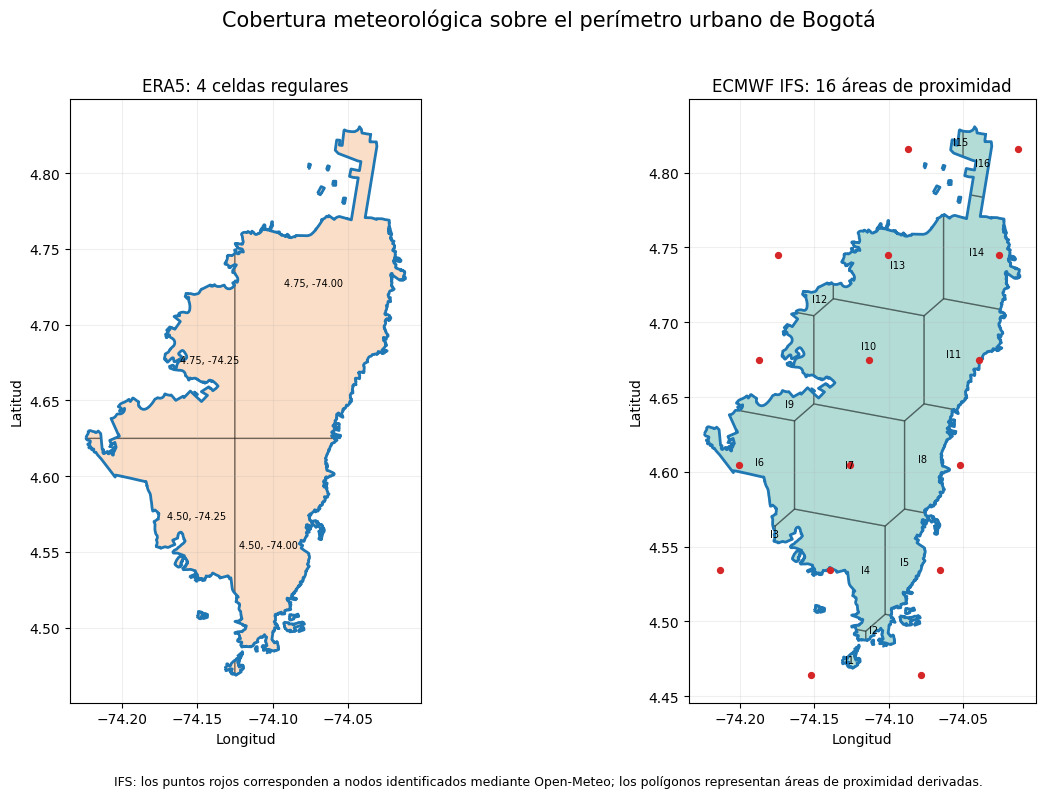

In [98]:
# Comparación visual de la cobertura espacial utilizada por ERA5 e ECMWF IFS
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

# Áreas correspondientes a ERA5 e IFS
malla_era5.plot(
    ax=axes[0],
    facecolor='#f4a261',
    edgecolor='black',
    alpha=0.35
)

malla_ifs.plot(
    ax=axes[1],
    facecolor='#2a9d8f',
    edgecolor='black',
    alpha=0.35
)

# Perímetro urbano de Bogotá sobre ambos mapas
for ax in axes:
    perimetro_urbano.to_crs(4326).boundary.plot(
        ax=ax,
        color='#1f77b4',
        linewidth=2
    )
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.grid(alpha=0.2)

# Nodos reales de ECMWF IFS identificados mediante Open-Meteo
nodos_ifs_plot.plot(
    ax=axes[1],
    color='#d62728',
    markersize=18,
    zorder=3
)

# Identificación de los nodos ERA5
for _, fila in malla_era5.iterrows():
    punto = fila.geometry.representative_point()
    axes[0].text(
        punto.x, punto.y, fila['NODO'],
        ha='center', va='center', fontsize=7
    )

# Identificación de las áreas asociadas a cada nodo IFS
for _, fila in malla_ifs.iterrows():
    punto = fila.geometry.representative_point()
    axes[1].text(
        punto.x, punto.y, fila['NODO'],
        ha='center', va='center', fontsize=7
    )

axes[0].set_title(f'ERA5: {len(malla_era5)} celdas regulares')
axes[1].set_title(f'ECMWF IFS: {len(malla_ifs)} áreas de proximidad')

plt.suptitle(
    'Cobertura meteorológica sobre el perímetro urbano de Bogotá',
    fontsize=15
)

plt.figtext(
    0.5, 0.01,
    'IFS: los puntos rojos corresponden a nodos identificados mediante Open-Meteo; '
    'los polígonos representan áreas de proximidad derivadas.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

La visualización muestra la diferencia espacial entre los dos modelos utilizados. ERA5 divide Bogotá en pocas áreas de gran tamaño, mientras que ECMWF IFS permite una asignación más detallada a partir de los nodos identificados con Open-Meteo.

En IFS, las áreas mostradas corresponden a zonas de proximidad construidas para asignar cada ubicación al nodo más cercano y no a celdas oficiales del modelo. Algunos nodos pueden quedar fuera del perímetro urbano y aun así ser necesarios para representar correctamente las zonas cercanas a los bordes de Bogotá.

### Selección de las variables climáticas finales

Se construye la tabla final de `CLIMA` conservando una sola observación por `CLIMA_ID` y únicamente los registros que cuentan con información meteorológica disponible. Las variables se renombran para mantener una estructura más clara y uniforme, incluyendo temperatura, humedad, sensación térmica, precipitación, lluvia, nubosidad, presión y viento.

Las coordenadas de celda y del modelo, la elevación, el nombre del modelo, la fuente y el código meteorológico se utilizan durante la construcción y validación de la relación, pero no se exportan. `CLIMA_ID` concentra la referencia entre cada accidente y su observación meteorológica, evitando almacenar metadatos repetidos que no se usarán como predictores.


In [99]:
# Solo se relacionan accidentes para los que se obtuvo información meteorológica
relacion_accidente_clima = (
    clima.loc[clima['temperature_2m'].notna(), ['ACCIDENTE_ID','CLIMA_ID']]
    .drop_duplicates('ACCIDENTE_ID')
)

# Creación de la tabla final de clima con registros únicos por accidente y clima
clima_final = clima.loc[clima['temperature_2m'].notna()].rename(columns={
    'temperature_2m':'TEMPERATURA_2M','relative_humidity_2m':'HUMEDAD_RELATIVA_2M',
    'apparent_temperature':'SENSACION_TERMICA','precipitation':'PRECIPITACION','rain':'LLUVIA',
    'cloud_cover':'NUBOSIDAD','surface_pressure':'PRESION_SUPERFICIE',
    'wind_speed_10m':'VELOCIDAD_VIENTO_10M','wind_direction_10m':'DIRECCION_VIENTO_10M',
})[[
    'CLIMA_ID','FECHA_HORA_CLIMA',
    'TEMPERATURA_2M','HUMEDAD_RELATIVA_2M','SENSACION_TERMICA','PRECIPITACION','LLUVIA',
    'NUBOSIDAD','PRESION_SUPERFICIE','VELOCIDAD_VIENTO_10M',
    'DIRECCION_VIENTO_10M'
]].drop_duplicates('CLIMA_ID')

### Resultado de la construcción de `CLIMA`

En esta etapa se valida la cobertura final de la información meteorológica y la correcta asignación de los modelos según el periodo de cada accidente. También se revisan las observaciones generadas, los nodos utilizados y la presencia de valores faltantes. Como criterio del proyecto, se espera que al menos el `95 %` de los accidentes elegibles cuente con información climática asociada.

In [100]:
# Resumen de la depuración de registros de la tabla CLIMA y su relación con la tabla ACCIDENTE
control_modelos = pd.DataFrame({
    'periodo': ['Antes de 2017', 'Desde 2017'],
    'modelo_esperado': ['era5', 'ecmwf_ifs'],
    'observaciones_climaticas': [
        clima_final['FECHA_HORA_CLIMA'].lt(CORTE_ECMWF_IFS).sum(),
        clima_final['FECHA_HORA_CLIMA'].ge(CORTE_ECMWF_IFS).sum(),
    ],
    'asignacion_correcta': [
        clima.loc[clima['FECHA_HORA_CLIMA'].lt(CORTE_ECMWF_IFS), 'MODELO'].eq('era5').all(),
        clima.loc[clima['FECHA_HORA_CLIMA'].ge(CORTE_ECMWF_IFS), 'MODELO'].eq('ecmwf_ifs').all(),
    ],
})
display(control_modelos)

,periodo,modelo_esperado,observaciones_climaticas,asignacion_correcta
0,Antes de 2017,era5,155274,True
1,Desde 2017,ecmwf_ifs,170040,True


La validación confirma que la asignación de los modelos climáticos se realizó correctamente según el periodo definido para el proyecto. Las observaciones anteriores a 2017 quedaron asociadas a ERA5 y las posteriores a ECMWF IFS, sin cruces entre ambos modelos. Esto permite mantener una transición consistente entre las dos fuentes dentro de la tabla `CLIMA`.

In [101]:
# Resumen de registros de la tabla CLIMA y su relación con la tabla ACCIDENTE
resultado_clima = pd.DataFrame([
    ['Accidentes elegibles para consultar clima', len(eventos_clima)],
    ['Accidentes relacionados con clima', len(relacion_accidente_clima)],
    ['Observaciones climáticas únicas', len(clima_final)],
    ['Duplicados evitados', len(relacion_accidente_clima) - len(clima_final)],
    ['Accidentes sin información climática', len(eventos_clima) - len(relacion_accidente_clima)],
    ['CLIMA_ID duplicados', clima_final['CLIMA_ID'].duplicated().sum()],
], columns=['resultado', 'cantidad'])
display(resultado_clima)

,resultado,cantidad
0,Accidentes elegibles para consultar clima,895833
1,Accidentes relacionados con clima,895833
2,Observaciones climáticas únicas,325314
3,Duplicados evitados,570519
4,Accidentes sin información climática,0
5,CLIMA_ID duplicados,0


La construcción de `CLIMA` logra relacionar todos los accidentes elegibles con una observación meteorológica. La reducción entre accidentes y observaciones únicas se debe a que varios eventos pueden compartir el mismo nodo, modelo y hora, por lo que reutilizan un mismo `CLIMA_ID`. Además, no quedan accidentes sin información climática ni identificadores duplicados, lo que confirma que la relación quedó completa y sin redundancias.

In [102]:
# Resumen de celdas utilizadas por modelo
control_celdas = (
    eventos_clima[['MODELO','LATITUD_CELDA','LONGITUD_CELDA']]
    .drop_duplicates()
    .groupby('MODELO', as_index=False)
    .size()
    .rename(columns={'size':'nodos_utilizados'})
)
display(control_celdas)

,MODELO,nodos_utilizados
0,ecmwf_ifs,15
1,era5,4


La cantidad de nodos utilizados refleja la diferencia de resolución espacial entre ambos modelos. ERA5 concentra la información en pocas celdas de mayor tamaño, mientras que ECMWF IFS distribuye los accidentes entre un mayor número de nodos, permitiendo una representación climática más detallada dentro del perímetro urbano.

In [103]:
# Resumen de registros faltantes en la tabla CLIMA
faltantes_clima = (clima_final.isna().sum()
    .rename('datos_faltantes').reset_index().rename(columns={'index':'variable'}))
faltantes_clima['porcentaje_faltante'] = (
    faltantes_clima['datos_faltantes'] / len(clima_final) * 100
).round(2)
display(faltantes_clima)
display(clima_final.head())

,variable,datos_faltantes,porcentaje_faltante
0,CLIMA_ID,0,0.0
1,FECHA_HORA_CLIMA,0,0.0
2,TEMPERATURA_2M,0,0.0
3,HUMEDAD_RELATIVA_2M,0,0.0
4,SENSACION_TERMICA,0,0.0
5,PRECIPITACION,0,0.0
6,LLUVIA,0,0.0
7,NUBOSIDAD,0,0.0
8,PRESION_SUPERFICIE,0,0.0
9,VELOCIDAD_VIENTO_10M,0,0.0


,CLIMA_ID,FECHA_HORA_CLIMA,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M
0,94817,2017-06-12 06:00:00,10.9,98,10.0,0.0,0.0,100,756.2,7.4,104
1,300449,2012-12-15 21:00:00,12.3,86,12.3,0.2,0.2,76,738.4,0.8,333
2,311806,2014-10-26 21:00:00,11.2,99,11.2,0.0,0.0,100,739.2,1.9,338
3,251355,2012-10-15 18:00:00,14.3,90,14.7,0.2,0.2,100,755.3,2.5,360
4,193825,2015-05-11 11:00:00,19.7,44,18.1,0.0,0.0,97,757.6,10.0,128


La tabla `CLIMA` queda completa para todas las variables seleccionadas, sin valores faltantes en las observaciones meteorológicas construidas. Esto permite utilizar la información climática sin necesidad de aplicar imputaciones adicionales y confirma que las descargas y validaciones realizadas fueron consistentes.

## 9. Construcción de la tabla ACCIDENTE depurada

En esta etapa se construye la tabla final de `ACCIDENTE` a partir de los registros que cumplen con las reglas de calidad y alcance definidas para PrediRuta. Se conservan el identificador, la fecha y hora, las coordenadas, la clase del accidente, la relación con `CLIMA` y la variable objetivo. Las variables de calendario se derivan de `FECHA_HORA` durante el modelado para evitar columnas redundantes. `CLASE_ACCIDENTE` se conserva como posible predictor de severidad cuando la clase ya es conocida; no debe utilizarse para una predicción previa a la ocurrencia del siniestro.

`LOCALIDAD` no se exporta porque la ubicación ya se conserva mediante `LATITUD` y `LONGITUD`; las unidades territoriales o espaciales necesarias para el modelo se derivarán posteriormente desde estas coordenadas.

In [104]:
# Creación de la variable objetivo antes de retirar GRAVEDAD del conjunto final
a['OBJETIVO_GRAVE'] = normalizar_categoria(a['GRAVEDAD']).ne('SOLO DANOS').astype('int8')

# Creación de la tabla final de ACCIDENTE con registros únicos por accidente y su relación con la tabla CLIMA
accidente_final = a.loc[a['REGISTRO_UTILIZABLE'], [
    'ACCIDENTE_ID','FECHA_HORA','LATITUD','LONGITUD','CLASE_ACC',
    'OBJETIVO_GRAVE'
]].rename(columns={'CLASE_ACC':'CLASE_ACCIDENTE'})
accidente_final = accidente_final.merge(
    relacion_accidente_clima, on='ACCIDENTE_ID', how='left', validate='1:1'
)
# Las variables temporales se derivarán de FECHA_HORA durante el modelado.


In [105]:
# Resumen de la depuración de registros de la tabla ACCIDENTE y su relación con la tabla CLIMA
resultado_accidente_final = pd.DataFrame([
    ['Accidentes originales', len(a)],
    ['Accidentes conservados', len(accidente_final)],
    ['Accidentes retirados', len(a) - len(accidente_final)],
    ['ACCIDENTE_ID duplicados', accidente_final['ACCIDENTE_ID'].duplicated().sum()],
    ['Registros con fecha o coordenadas faltantes', accidente_final[['FECHA_HORA','LATITUD','LONGITUD']].isna().any(axis=1).sum()],
], columns=['resultado', 'cantidad'])

display(resultado_accidente_final)
display(accidente_final.head())

,resultado,cantidad
0,Accidentes originales,904476
1,Accidentes conservados,895833
2,Accidentes retirados,8643
3,ACCIDENTE_ID duplicados,0
4,Registros con fecha o coordenadas faltantes,0


,ACCIDENTE_ID,FECHA_HORA,LATITUD,LONGITUD,CLASE_ACCIDENTE,OBJETIVO_GRAVE,CLIMA_ID
0,4484660,2017-06-12 05:30:00,4.693807,-74.090924,CHOQUE,0,94817
1,449558,2012-12-15 20:30:00,4.669288,-74.040677,CHOQUE,0,300449
2,513150,2014-10-26 21:25:00,4.679568,-74.087407,ATROPELLO,1,311806
3,443270,2012-10-15 18:00:00,4.662473,-74.13335,CHOQUE,0,251355
4,4412699,2015-05-11 10:50:00,4.587187,-74.166937,CHOQUE,0,193825


La tabla final de `ACCIDENTE` conserva prácticamente toda la información que cumple con los criterios definidos para PrediRuta. Los registros retirados corresponden principalmente a las decisiones de alcance aplicadas previamente y, en la base final, no se presentan identificadores duplicados ni faltantes en las variables básicas de fecha y ubicación. Con esto se obtiene una tabla consistente para continuar con el análisis y la construcción del modelo.

## 10. Estadísticas descriptivas de las tablas finales

En esta etapa se revisan las variables numéricas y categóricas de las tablas finales antes de exportarlas. Para las variables numéricas analíticas se calculan valores válidos y faltantes, mínimo, máximo, promedio, desviación estándar, moda y percentiles 5, 25, 50, 75 y 95. Los identificadores y las fechas se excluyen de este resumen porque esas medidas no tienen una interpretación estadística útil.

In [106]:
# Resumen de estadísticas descriptivas de todas las variables numéricas analíticas
# Se excluyen identificadores y fechas porque sus medidas de tendencia y percentiles no son interpretables.
variables_numericas = {
    'ACCIDENTE': (accidente_final, ['LATITUD','LONGITUD','OBJETIVO_GRAVE']),
    'VIA': (via_final, ['N_CALZADAS','N_CARRILES']),
    'ACTOR_VIAL': (actor_final, ['EDAD']),
    'CLIMA': (clima_final, [
        'TEMPERATURA_2M','HUMEDAD_RELATIVA_2M','SENSACION_TERMICA',
        'PRECIPITACION','LLUVIA','NUBOSIDAD','PRESION_SUPERFICIE',
        'VELOCIDAD_VIENTO_10M','DIRECCION_VIENTO_10M',
    ]),
}

descriptivas = []
for nombre, (tabla, variables) in variables_numericas.items():
    for variable in variables:
        valores = pd.to_numeric(tabla[variable], errors='coerce')
        valores_validos = valores.dropna()
        moda = valores_validos.mode()
        percentiles = valores_validos.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
        descriptivas.append([
            nombre, variable, valores.notna().sum(), valores.isna().sum(),
            valores.min(),
            percentiles.get(0.05, pd.NA),
            percentiles.get(0.25, pd.NA),
            percentiles.get(0.50, pd.NA),
            percentiles.get(0.75, pd.NA),
            percentiles.get(0.95, pd.NA),
            valores.max(), valores.mean(), valores.std(),
            moda.iloc[0] if not moda.empty else pd.NA,
        ])

descriptivas = pd.DataFrame(descriptivas, columns=[
    'tabla','variable','datos_validos','datos_faltantes','minimo',
    'percentil_05','percentil_25','mediana','percentil_75','percentil_95',
    'maximo','promedio','desviacion_estandar','moda',
])

display(descriptivas.round(2))

,tabla,variable,datos_validos,datos_faltantes,minimo,percentil_05,percentil_25,mediana,percentil_75,percentil_95,maximo,promedio,desviacion_estandar,moda
0,ACCIDENTE,LATITUD,895833,0,4.47,4.56,4.61,4.65,4.69,4.74,4.82,4.65,0.06,4.60
1,ACCIDENTE,LONGITUD,895833,0,-74.22,-74.17,-74.13,-74.10,-74.07,-74.04,-74.01,-74.10,0.04,-74.09
2,ACCIDENTE,OBJETIVO_GRAVE,895833,0,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.38,0.49,0.00
3,VIA,N_CALZADAS,485701,2961,1.00,1.00,1.00,1.00,2.00,3.00,5.00,1.40,0.67,1.00
4,VIA,N_CARRILES,486926,1736,1.00,1.00,2.00,2.00,3.00,3.00,4.00,2.26,0.69,2.00
5,ACTOR_VIAL,EDAD,1885212,43368,-7624.00,19.00,27.00,35.00,46.00,62.00,2021.00,37.51,22.74,27.00
6,CLIMA,TEMPERATURA_2M,325314,0,0.10,9.10,12.00,14.30,17.20,19.90,26.10,14.48,3.40,12.40
7,CLIMA,HUMEDAD_RELATIVA_2M,325314,0,6.00,45.00,62.00,78.00,91.00,98.00,100.00,75.21,17.55,95.00
8,CLIMA,SENSACION_TERMICA,325314,0,-2.70,7.50,11.10,13.60,16.30,19.50,26.60,13.64,3.67,12.70
9,CLIMA,PRECIPITACION,325314,0,0.00,0.00,0.00,0.00,0.10,0.90,13.60,0.17,0.53,0.00


Las estadísticas permiten identificar dos hallazgos que se corrigen en la siguiente celda, antes de validar y exportar los archivos:

- Los valores faltantes de `N_CALZADAS` se completan con `1`, su moda.
- Los valores faltantes de `N_CARRILES` se completan con `2`, valor consistente con su moda, promedio y mediana.
- Los accidentes que contienen al menos una edad fuera del rango de `0` a `110` años se retiran de todas las tablas finales junto con sus registros relacionados.

In [107]:
# Ajustes derivados de la revisión de las estadísticas descriptivas

# Imputación de los datos viales faltantes con los valores definidos a partir de la moda
faltantes_n_calzadas = pd.to_numeric(via_final['N_CALZADAS'], errors='coerce').isna().sum()
faltantes_n_carriles = pd.to_numeric(via_final['N_CARRILES'], errors='coerce').isna().sum()
via_final['N_CALZADAS'] = pd.to_numeric(
    via_final['N_CALZADAS'], errors='coerce'
).fillna(1).astype('int8')
via_final['N_CARRILES'] = pd.to_numeric(
    via_final['N_CARRILES'], errors='coerce'
).fillna(2).astype('int8')

display(pd.DataFrame([
    ['N_CALZADAS', faltantes_n_calzadas, 1],
    ['N_CARRILES', faltantes_n_carriles, 2],
], columns=['variable', 'datos_completados', 'valor_utilizado']))

# Identificación de accidentes con edades imposibles
edad_actor = pd.to_numeric(actor_final['EDAD'], errors='coerce')
mascara_edad_invalida = edad_actor.notna() & ~edad_actor.between(0, 110)
accidentes_edad_invalida = set(
    actor_final.loc[mascara_edad_invalida, 'ACCIDENTE_ID'].dropna()
)

filas_antes = {
    'ACCIDENTE': len(accidente_final),
    'VIA': len(via_final),
    'VEHICULO': len(vehiculo_final),
    'ACTOR_VIAL': len(actor_final),
    'CAUSA': len(causa_final),
    'CLIMA': len(clima_final),
}

# Exclusión en cascada de accidentes con edades imposibles
accidente_final = accidente_final[
    ~accidente_final['ACCIDENTE_ID'].isin(accidentes_edad_invalida)
].copy()
via_final = via_final[
    ~via_final['ACCIDENTE_ID'].isin(accidentes_edad_invalida)
].copy()
vehiculo_final = vehiculo_final[
    ~vehiculo_final['ACCIDENTE_ID'].isin(accidentes_edad_invalida)
].copy()
actor_final = actor_final[
    ~actor_final['ACCIDENTE_ID'].isin(accidentes_edad_invalida)
].copy()
causa_final = causa_final[
    ~causa_final['ACCIDENTE_ID'].isin(accidentes_edad_invalida)
].copy()

# Exclusión en cascada de registros climáticos asociados a accidentes retirados
clima_ids_utilizados = set(accidente_final['CLIMA_ID'].dropna())
clima_final = clima_final[clima_final['CLIMA_ID'].isin(clima_ids_utilizados)].copy()

filas_despues = {
    'ACCIDENTE': len(accidente_final),
    'VIA': len(via_final),
    'VEHICULO': len(vehiculo_final),
    'ACTOR_VIAL': len(actor_final),
    'CAUSA': len(causa_final),
    'CLIMA': len(clima_final),
}

# Resumen de la exclusión en cascada de accidentes con edades imposibles y su impacto en las tablas finales
resumen_exclusion_edad = pd.DataFrame([
    [tabla, filas_antes[tabla], filas_despues[tabla]]
    for tabla in filas_antes
], columns=['tabla', 'filas_antes', 'filas_despues'])
resumen_exclusion_edad['filas_retiradas'] = (
    resumen_exclusion_edad['filas_antes'] - resumen_exclusion_edad['filas_despues']
)

print(f'Accidentes retirados por edades imposibles: {len(accidentes_edad_invalida):,}')
display(resumen_exclusion_edad.reset_index(drop=True))


,variable,datos_completados,valor_utilizado
0,N_CALZADAS,2961,1
1,N_CARRILES,1736,2


Accidentes retirados por edades imposibles: 487


,tabla,filas_antes,filas_despues,filas_retiradas
0,ACCIDENTE,895833,895346,487
1,VIA,488662,488413,249
2,VEHICULO,1670699,1669752,947
3,ACTOR_VIAL,1928580,1927486,1094
4,CAUSA,1284682,1283835,847
5,CLIMA,325314,325230,84


In [109]:
# Resumen de estadísticas descriptivas de todas las variables categóricas finales
variables_categoricas = {
    'ACCIDENTE': (accidente_final, [
        'CLASE_ACCIDENTE',
    ]),
    'VIA': (via_final, [
        'GEOMETRIA_PLANTA','GEOMETRIA_TERRENO','GEOMETRIA_SECCION','SENTIDO_VIA',
        'SUPERFICIE_RODADURA','ESTADO_VIA','CONDICION_VIA',
        'ILUMINACION_ARTIFICIAL','SEMAFORO',
    ]),
    'VEHICULO': (vehiculo_final, ['CLASE','SERVICIO']),
    'ACTOR_VIAL': (actor_final, ['CONDICION','ESTADO','GENERO']),
    'CAUSA': (causa_final, ['CODIGO_CAUSA','NOMBRE','TIPO']),
}

# Verificar que ninguna columna categórica haya quedado fuera del resumen
columnas_excluidas_resumen_categorico = {'ACCIDENTE': {'FECHA_HORA'}}
categoricas_omitidas = {}
for nombre, (tabla, variables) in variables_categoricas.items():
    detectadas = {
        columna for columna in tabla.columns
        if not pd.api.types.is_numeric_dtype(tabla[columna])
        and not pd.api.types.is_datetime64_any_dtype(tabla[columna])
    }
    omitidas = (
        detectadas - set(variables)
        - columnas_excluidas_resumen_categorico.get(nombre, set())
    )
    if omitidas:
        categoricas_omitidas[nombre] = sorted(omitidas)

if categoricas_omitidas:
    raise ValueError(f'Variables categóricas fuera del resumen: {categoricas_omitidas}')

resumen_categorias = []
for nombre, (tabla, variables) in variables_categoricas.items():
    for variable in variables:
        conteo = tabla[variable].value_counts(dropna=True)
        datos_faltantes = tabla[variable].isna().sum()
        resumen_categorias.append([
            nombre, variable, tabla[variable].nunique(dropna=True),
            conteo.index[0] if len(conteo) else pd.NA,
            conteo.iloc[0] if len(conteo) else 0,
            datos_faltantes,
            datos_faltantes / len(tabla) * 100 if len(tabla) else 0,
        ])

resumen_categorias = pd.DataFrame(resumen_categorias, columns=[
    'tabla','variable','categorias','valor_mas_frecuente','frecuencia',
    'datos_faltantes','porcentaje_faltantes',
])

display(resumen_categorias.round({'porcentaje_faltantes': 2}))

,tabla,variable,categorias,valor_mas_frecuente,frecuencia,datos_faltantes,porcentaje_faltantes
0,ACCIDENTE,CLASE_ACCIDENTE,7,CHOQUE,742846,278,0.03
1,VIA,GEOMETRIA_PLANTA,6,RECTA,471712,193,0.04
2,VIA,GEOMETRIA_TERRENO,6,PLANO,459287,3466,0.71
3,VIA,GEOMETRIA_SECCION,7,CON ANDEN,346110,30851,6.32
4,VIA,SENTIDO_VIA,5,UN SENTIDO,292472,2054,0.42
5,VIA,SUPERFICIE_RODADURA,7,ASFALTO,435029,2328,0.48
6,VIA,ESTADO_VIA,9,BUENO,466456,3150,0.64
7,VIA,CONDICION_VIA,8,SECA,442657,1535,0.31
8,VIA,ILUMINACION_ARTIFICIAL,2,SIN,251211,16034,3.28
9,VIA,SEMAFORO,2,NO,273900,0,0.00


Las variables categóricas muestran una concentración importante en algunas categorías principales, especialmente en `ACCIDENTE`, `VIA`, `VEHICULO` y `ACTOR_VIAL`. También se observan variables con mayor cantidad de categorías, como `CAUSA`, que podrían requerir agrupación antes del modelado para evitar niveles con poca representación.

Antes de exportar, los nombres de causa faltantes se intentan recuperar mediante `CODIGO_CAUSA`, utilizando el nombre observado para ese mismo código. Los casos que no pueden recuperarse y los demás valores categóricos faltantes se completan con `SIN INFORMACION`; no se utiliza la moda porque podría atribuir una característica que la fuente no reportó.

In [110]:
# Ajustes derivados de la revisión de las variables categóricas

# Normalizar los nombres vacíos antes de construir el catálogo código-nombre
causa_final['NOMBRE'] = (
    causa_final['NOMBRE'].astype('string').str.strip().replace('', pd.NA)
)
nombres_faltantes_antes = causa_final['NOMBRE'].isna().sum()

catalogo_nombre_causa = (
    causa_final.dropna(subset=['CODIGO_CAUSA', 'NOMBRE'])
    .groupby('CODIGO_CAUSA')['NOMBRE']
    .agg(lambda valores: valores.mode().iloc[0])
)
mascara_nombre_faltante = causa_final['NOMBRE'].isna()
causa_final.loc[mascara_nombre_faltante, 'NOMBRE'] = (
    causa_final.loc[mascara_nombre_faltante, 'CODIGO_CAUSA']
    .map(catalogo_nombre_causa)
)
nombres_recuperados_por_codigo = (
    nombres_faltantes_antes - causa_final['NOMBRE'].isna().sum()
)

# Representar de forma explícita los datos categóricos que la fuente no informa
resumen_completado_categoricas = []
for nombre, (tabla, variables) in variables_categoricas.items():
    for variable in variables:
        valores = tabla[variable].astype('string').str.strip().replace('', pd.NA)
        faltantes = valores.isna().sum()
        tabla[variable] = valores.fillna('SIN INFORMACION')
        resumen_completado_categoricas.append([nombre, variable, faltantes])

if any(
    tabla[variable].isna().any()
    for tabla, variables in variables_categoricas.values()
    for variable in variables
):
    raise ValueError('Persisten datos faltantes en las variables categóricas.')

print(f'Nombres de causa recuperados mediante CODIGO_CAUSA: {nombres_recuperados_por_codigo:,}')
display(pd.DataFrame(
    resumen_completado_categoricas,
    columns=['tabla', 'variable', 'datos_completados_con_sin_informacion'],
))


Nombres de causa recuperados mediante CODIGO_CAUSA: 4


,tabla,variable,datos_completados_con_sin_informacion
0,ACCIDENTE,CLASE_ACCIDENTE,278
1,VIA,GEOMETRIA_PLANTA,193
2,VIA,GEOMETRIA_TERRENO,3466
3,VIA,GEOMETRIA_SECCION,30851
4,VIA,SENTIDO_VIA,2054
5,VIA,SUPERFICIE_RODADURA,2328
6,VIA,ESTADO_VIA,3150
7,VIA,CONDICION_VIA,1535
8,VIA,ILUMINACION_ARTIFICIAL,16034
9,VIA,SEMAFORO,0


## 11. Validaciones finales de las tablas depuradas

Antes de guardar las tablas finales se revisa la integridad entre ellas y la unicidad de sus llaves. También se verifica que no existan accidentes huérfanos y que las referencias a `CLIMA` sean válidas. Con estas pruebas se confirma que cada tabla mantiene la estructura esperada antes de su exportación.

In [111]:
# Validación de integridad y consistencia de las tablas finales
tablas_salida = {
    'ACCIDENTE': accidente_final, 'VIA': via_final, 'CLIMA': clima_final,
    'VEHICULO': vehiculo_final, 'ACTOR_VIAL': actor_final, 'CAUSA': causa_final,
}

validaciones = [] # Lista para almacenar los resultados de las validaciones

# Validación de accidentes huérfanos en las tablas relacionadas
ids_finales = set(accidente_final['ACCIDENTE_ID'])
for nombre in ['ACCIDENTE','VIA','VEHICULO','ACTOR_VIAL','CAUSA']: # Iteración sobre las tablas relacionadas con accidentes
    tabla = tablas_salida[nombre]
    validaciones.append((nombre, 'Sin accidentes huérfanos', tabla['ACCIDENTE_ID'].isin(ids_finales).all()))

# Validación de claves únicas y referencias válidas en las tablas finales
validaciones += [
    ('ACCIDENTE','PK única', accidente_final['ACCIDENTE_ID'].is_unique),
    ('VIA','Una fila por accidente', via_final['ACCIDENTE_ID'].is_unique),
    ('CLIMA','CLIMA_ID único', clima_final['CLIMA_ID'].is_unique),
    ('CLIMA','Referencias válidas', accidente_final['CLIMA_ID'].dropna().isin(set(clima_final['CLIMA_ID'])).all()),
    ('VEHICULO','Clave única', vehiculo_final['VEHICULO_ID'].is_unique),
    ('ACTOR_VIAL','Clave única', actor_final['ACTOR_ID'].is_unique),
    ('CAUSA','Clave única', causa_final['CAUSA_ID'].is_unique),
    ('ACTOR_VIAL','Vehículos válidos', actor_final['VEHICULO_ID'].dropna().isin(set(vehiculo_final['VEHICULO_ID'])).all()),
    ('CAUSA','Vehículos válidos', causa_final['VEHICULO_ID'].dropna().isin(set(vehiculo_final['VEHICULO_ID'])).all()),
]

# Creación de un DataFrame con los resultados de las validaciones y visualización de los resultados
validaciones = pd.DataFrame(validaciones, columns=['tabla','prueba','cumple'])

display(validaciones)
display(validaciones.groupby('tabla', as_index=False)['cumple'].all().rename(columns={'cumple':'tabla_lista_para_exportar'}))

,tabla,prueba,cumple
0,ACCIDENTE,Sin accidentes huérfanos,True
1,VIA,Sin accidentes huérfanos,True
2,VEHICULO,Sin accidentes huérfanos,True
3,ACTOR_VIAL,Sin accidentes huérfanos,True
4,CAUSA,Sin accidentes huérfanos,True
5,ACCIDENTE,PK única,True
6,VIA,Una fila por accidente,True
7,CLIMA,CLIMA_ID único,True
8,CLIMA,Referencias válidas,True
9,VEHICULO,Clave única,True


,tabla,tabla_lista_para_exportar
0,ACCIDENTE,True
1,ACTOR_VIAL,True
2,CAUSA,True
3,CLIMA,True
4,VEHICULO,True
5,VIA,True


## 12. Exportación de las tablas depuradas

Después de revisar los resultados y las validaciones, se exportan las seis tablas finales como archivos CSV. Las fuentes originales no se modifican.

La codificación de variables categóricas, la creación de momentos sin accidente y la construcción de las tablas analíticas completas se realizan posteriormente en `construccion_dataset.ipynb`.


In [112]:
# Exportación de las tablas depuradas a archivos CSV
SALIDA = Path('data_procesada/tablas_finales')
SALIDA.mkdir(parents=True, exist_ok=True)

# Exportación de cada tabla a un archivo CSV con codificación UTF-8 con BOM
for nombre, tabla in tablas_salida.items():
    tabla.to_csv(SALIDA / f'{nombre}.csv', index=False, encoding='utf-8-sig')

resumen_exportacion = pd.DataFrame({
    'tabla': list(tablas_salida),
    'filas_exportadas': [len(tabla) for tabla in tablas_salida.values()],
    'columnas_exportadas': [len(tabla.columns) for tabla in tablas_salida.values()],
    'archivo_csv': [str(SALIDA / f'{nombre}.csv') for nombre in tablas_salida],
})

display(resumen_exportacion)

,tabla,filas_exportadas,columnas_exportadas,archivo_csv
0,ACCIDENTE,895346,7,data_procesada/tablas_finales/ACCIDENTE.csv
1,VIA,488413,12,data_procesada/tablas_finales/VIA.csv
2,CLIMA,325230,11,data_procesada/tablas_finales/CLIMA.csv
3,VEHICULO,1669752,4,data_procesada/tablas_finales/VEHICULO.csv
4,ACTOR_VIAL,1927486,7,data_procesada/tablas_finales/ACTOR_VIAL.csv
5,CAUSA,1283835,6,data_procesada/tablas_finales/CAUSA.csv
